# COMP0051 Algorithmic Trading Project

In [29]:
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from fredapi import Fred
import ccxt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
load_dotenv()

True

### Crypto Data Download

In [30]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "ADA/USDT"]
TIMEFRAME  = "1d"
SINCE      = "2020-01-01"
UNTIL      = "2026-03-20"
DATA_DIR   = Path("data_final")
DATA_DIR.mkdir(parents=True, exist_ok=True)

exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")
until_ms = exchange.parse8601(f"{UNTIL}T23:59:59Z")

for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME, since=since, limit=1000)
        if not bars:
            break

        bars = [bar for bar in bars if bar[0] <= until_ms]
        if not bars:
            break

        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        if bars[-1][0] >= until_ms:
            break

    df = pd.DataFrame(
        all_bars,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    df.to_parquet(fname, engine="pyarrow")
    print(f" {len(df):,} bars -> {fname}")

print("Done.")

Done.


### Macro Data - Effective Fed Funds Rate (FRED)

In [31]:
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE, observation_end=UNTIL)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 2,271 observations → data_final/DFF_daily.parquet


date
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
2026-03-18 00:00:00+00:00    3.64
2026-03-19 00:00:00+00:00    3.64
2026-03-20 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Quality Checks & Cleaning

In [32]:
VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
PANDAS_FREQ = str(TIMEFRAME).upper()


def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.sort_index().copy()
    frame = frame[~frame.index.duplicated(keep="first")]

    for col in VALUE_COLUMNS:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

    valid = (
        frame[VALUE_COLUMNS].notna().all(axis=1)
        & (frame[["open", "high", "low", "close"]] > 0).all(axis=1)
        & (frame["volume"] >= 0)
        & (frame["high"] >= frame["low"])
        & (frame["high"] >= frame[["open", "close"]].max(axis=1))
        & (frame["low"] <= frame[["open", "close"]].min(axis=1))
    )
    frame = frame.loc[valid].copy()

    r = frame["close"].pct_change()
    z = (r - r.rolling(30, min_periods=10).mean()) / r.rolling(30, min_periods=10).std(ddof=0).replace(0.0, np.nan)
    frame["simple_return"] = r
    frame["return_zscore"] = z
    frame["is_outlier"] = z.abs().gt(5.0).fillna(False)
    return frame


def quick_audit(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    idx = pd.DatetimeIndex(df.index)
    expected = pd.date_range(idx.min(), idx.max(), freq=PANDAS_FREQ, tz="UTC")
    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(df),
        "duplicates": int(idx.duplicated().sum()),
        "missing_bars": int(len(expected.difference(idx))),
        "null_rows": int(df[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "outliers": int(df["is_outlier"].sum()) if "is_outlier" in df else 0,
    }


cleaned_frames = {}
audit_rows = []

for symbol in SYMBOLS:
    key = symbol.replace("/", "")
    raw_path = DATA_DIR / f"{key}_{TIMEFRAME}.parquet"

    raw = pd.read_parquet(raw_path)
    raw.index = pd.to_datetime(raw.index, utc=True)
    clean = clean_ohlcv(raw)

    clean_path = DATA_DIR / f"{key}_{TIMEFRAME}_cleaned.parquet"
    clean.to_parquet(clean_path, engine="pyarrow")

    cleaned_frames[symbol] = clean
    audit_rows.append(quick_audit(raw, symbol, "raw"))
    audit_rows.append(quick_audit(clean, symbol, "cleaned"))

quality_report = pd.DataFrame(audit_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
quality_report

,symbol,stage,rows,duplicates,missing_bars,null_rows,outliers
0,ADA/USDT,cleaned,2271,0,0,0,1
1,ADA/USDT,raw,2271,0,0,0,0
2,BTC/USDT,cleaned,2271,0,0,0,0
3,BTC/USDT,raw,2271,0,0,0,0
4,DOGE/USDT,cleaned,2271,0,0,0,1
5,DOGE/USDT,raw,2271,0,0,0,0
6,ETH/USDT,cleaned,2271,0,0,0,0
7,ETH/USDT,raw,2271,0,0,0,0


##### Cleaning Results

- **No structural data issues were found** in either stage: all symbols have `duplicates = 0`, `missing_bars = 0`, and `null_rows = 0`.
- **Row counts are unchanged** (`2271` raw and `2271` cleaned), so no rows were dropped by the current cleaning rules.
- For this run, **1 outlier was flagged in `ADA/USDT` and `DOGE/USDT`**, and none in `BTC/USDT` or `ETH/USDT`.

> Note: Outliers are **flagged, not removed**.

### Excess Returns Series

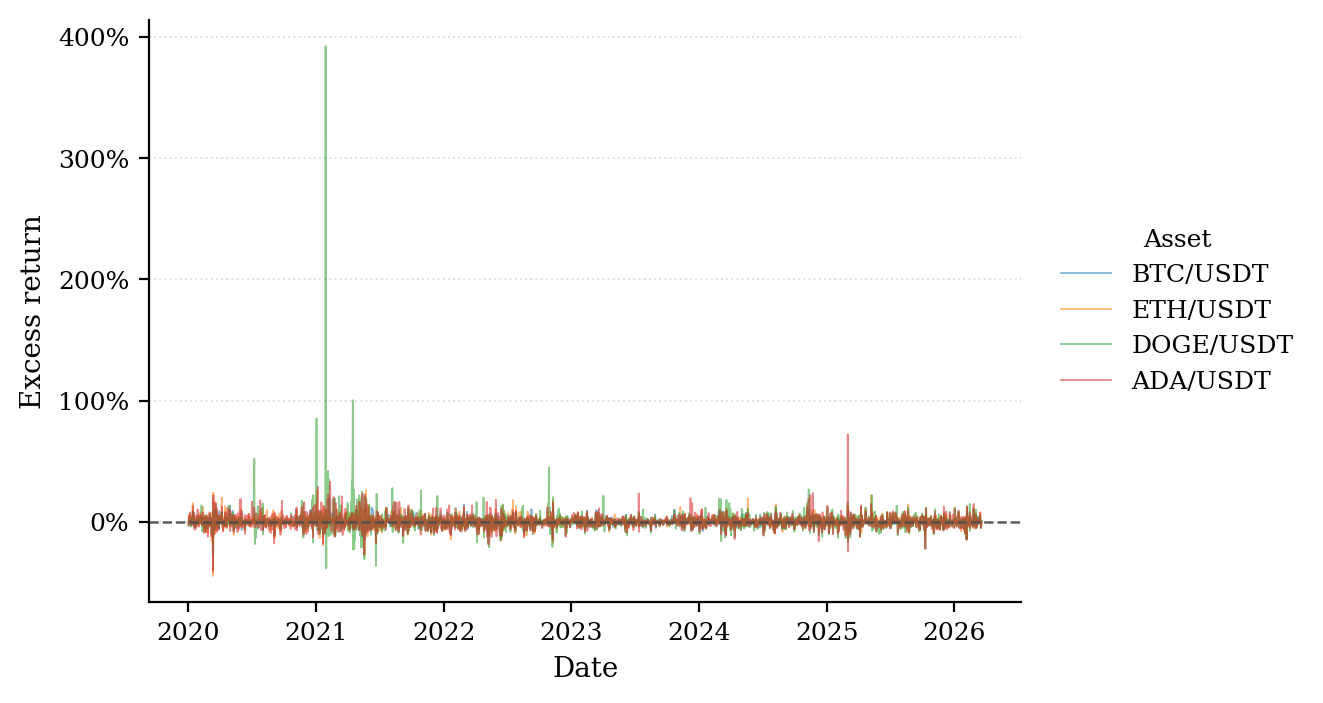

,mean,std,min,max
BTC/USDT,0.001464,0.032319,-0.395078,0.195359
ETH/USDT,0.002113,0.043330,-0.445999,0.263327
DOGE/USDT,0.004596,0.105249,-0.384395,3.924112
ADA/USDT,0.002232,0.053569,-0.413232,0.721407


In [33]:
# Convert FRED DFF (annual %, simple) to an approximate daily return.
rf_daily = ((1 + dff / 100.0) ** (1 / 365.0) - 1).rename("rf_daily")
rf_daily = rf_daily.reindex(pd.date_range(dff.index.min(), dff.index.max(), freq="D", tz="UTC")).ffill()

excess_returns = {}
for symbol in SYMBOLS:
    asset = cleaned_frames[symbol].copy()
    asset_return = asset["close"].pct_change().rename("asset_return")
    aligned_rf = rf_daily.reindex(asset.index).ffill().rename("rf_daily")

    asset["rf_daily"] = aligned_rf
    asset["excess_return"] = asset_return - aligned_rf
    cleaned_frames[symbol] = asset

    excess_returns[symbol] = asset["excess_return"].rename(symbol)

excess_returns_df = pd.concat(excess_returns.values(), axis=1).dropna(how="all")
excess_returns_df.head()

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

colors = plt.get_cmap("tab10").colors

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)

for i, col in enumerate(excess_returns_df.columns):
    c = colors[i % len(colors)]
    ax.plot(
        excess_returns_df.index,
        excess_returns_df[col],
        color=c,
        linewidth=0.65,
        alpha=0.55,
        label=col,
    )

ax.axhline(0.0, color="0.3", linewidth=0.9, linestyle="--", alpha=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Excess return")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.4)
ax.grid(False, axis="x")

ax.legend(title="Asset", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "daily_excess_returns.pdf", bbox_inches="tight")
fig.savefig(out_dir / "daily_excess_returns.png", bbox_inches="tight")

plt.show()

excess_returns_df.describe().T[["mean", "std", "min", "max"]]


### Transaction Costs / Slippage (Abdi & Ranaldo)

,abdi_ranaldo_spread
timestamp,
2026-03-16 00:00:00+00:00,0.010394
2026-03-17 00:00:00+00:00,0.007352
2026-03-18 00:00:00+00:00,0.007219
2026-03-19 00:00:00+00:00,0.010892
2026-03-20 00:00:00+00:00,0.010340


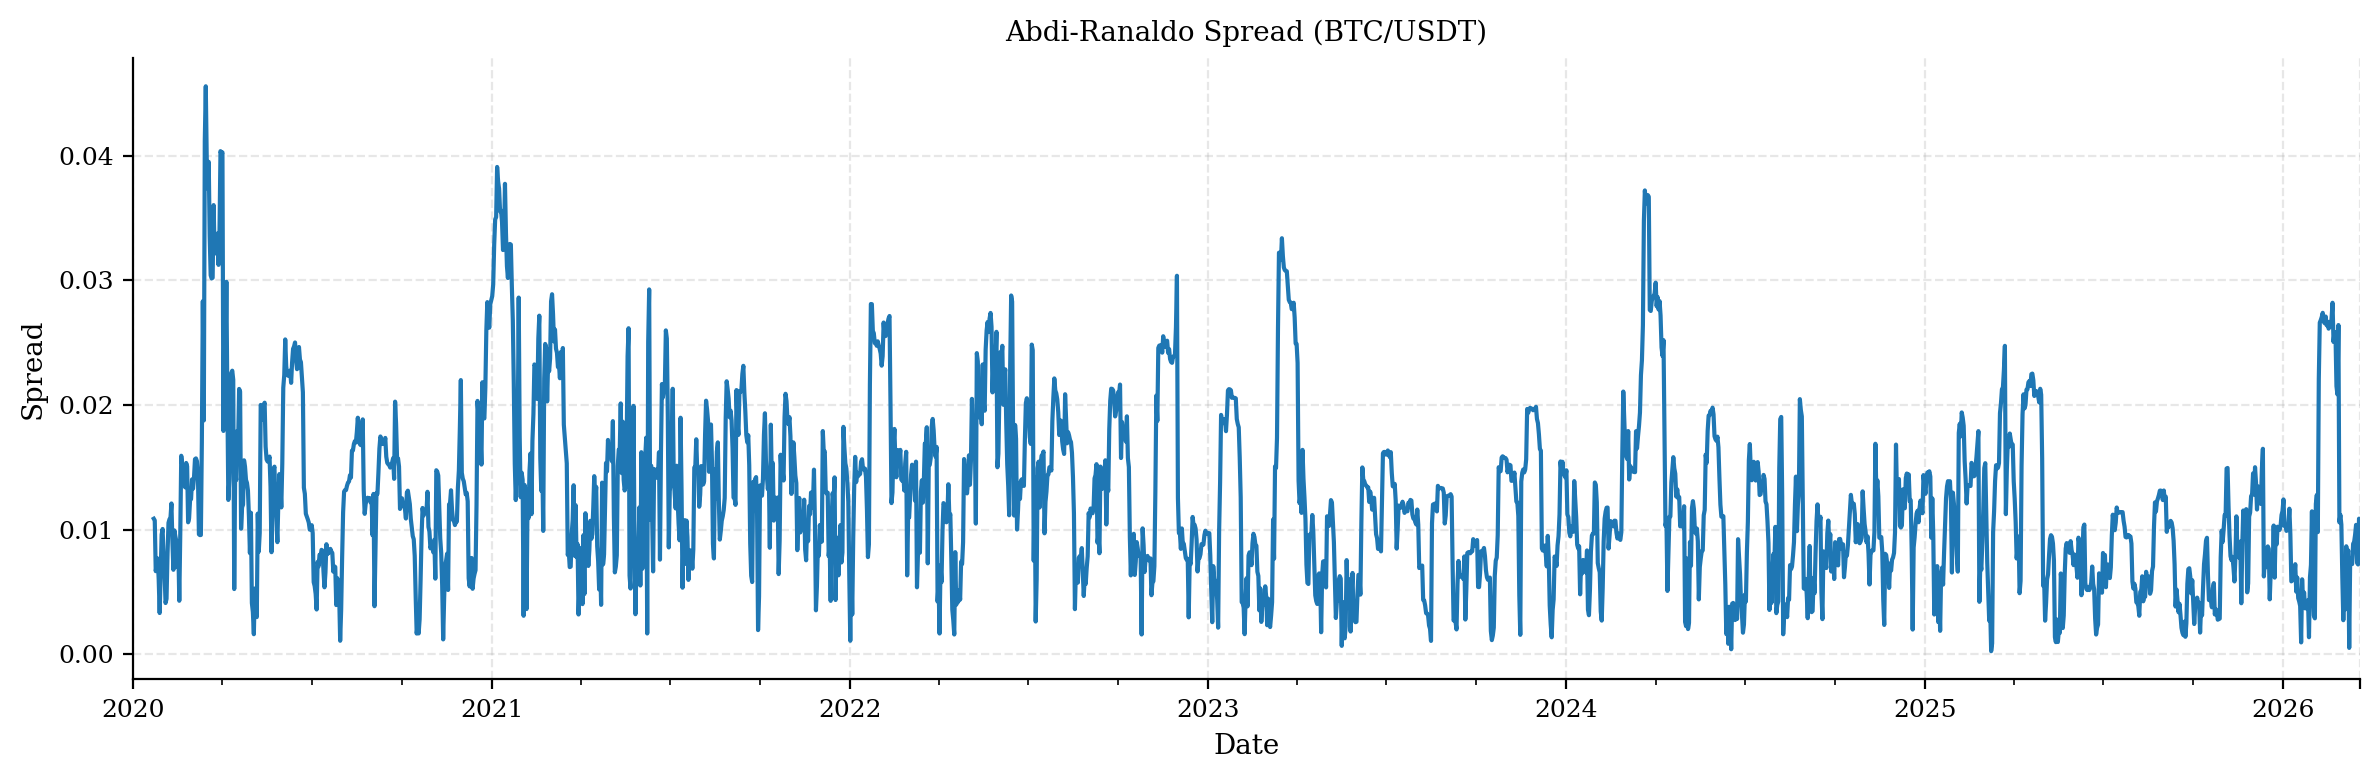

In [34]:
def abdi_ranaldo_spread(frame: pd.DataFrame, window: int = 21) -> pd.Series:
    cols = {col.lower(): col for col in frame.columns}
    required = {"high", "low", "close"}
    missing = required.difference(cols)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    high = pd.to_numeric(frame[cols["high"]], errors="coerce")
    low = pd.to_numeric(frame[cols["low"]], errors="coerce")
    close = pd.to_numeric(frame[cols["close"]], errors="coerce")

    log_high = np.log(high.where(high > 0))
    log_low = np.log(low.where(low > 0))
    log_close = np.log(close.where(close > 0))

    midpoint = (log_high + log_low) / 2.0
    s2 = 4.0 * (log_close.shift(1) - midpoint.shift(1)) * (log_close.shift(1) - midpoint)
    spread = np.sqrt(s2.rolling(window=window, min_periods=window).mean().abs())
    return spread.replace([np.inf, -np.inf], np.nan).rename("abdi_ranaldo_spread")


if "cleaned_frames" in globals() and isinstance(cleaned_frames, dict) and cleaned_frames:
    for symbol, frame in cleaned_frames.items():
        frame["abdi_ranaldo_spread"] = abdi_ranaldo_spread(frame)
    spread_label = next(iter(cleaned_frames))
    spread_df = cleaned_frames[spread_label]
elif "df" in globals() and isinstance(df, pd.DataFrame):
    df["abdi_ranaldo_spread"] = abdi_ranaldo_spread(df)
    spread_df = df
    spread_label = "df"
else:
    raise NameError("No existing dataframe found. Expected a non-empty `cleaned_frames` dictionary or `df`.")

display(spread_df[["abdi_ranaldo_spread"]].tail())

ax = spread_df["abdi_ranaldo_spread"].plot(figsize=(12, 4), title=f"Abdi-Ranaldo Spread ({spread_label})")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Strategy 1: Walk-Forward Optimised Signed Trend-Following

**Signal**: Signed, standardised MA crossover. For each asset, the fast/slow MA spread is divided by a rolling spread-volatility estimate, passed through a hysteresis filter to produce persistent long, short, or flat states, and then scaled into a continuous signal with $\tanh(|z|)$. The final signed signal is lagged one day.

**Deployment**: On each weekly rebalance, the strategy keeps only the strongest assets by absolute signal, combines covariance-aware base weights with signal-strength magnitudes, applies the signal sign, and then volatility-targets the resulting signed portfolio subject to leverage and gross-notional caps.

**Optimisation**: Expanding-window walk-forward over a grid of $(MA_{\text{fast}}, MA_{\text{slow}}, \text{entry}, \text{exit ratio}, \text{top }N)$ signal settings, with a validation-aware robust score and cash fallback when no candidate is genuinely tradable.


In [35]:
# === Walk-Forward Signed Trend-Following Strategy ===
# Broader parameter search with train/validation scoring inside each fold,
# weekly rebalancing, covariance-aware sizing, and explicit leverage control.

from itertools import product

# ── Configuration ─────────────────────────────────────────────────
MIN_TRAIN_DAYS = 365
VALID_DAYS = 120
TEST_DAYS = 180

# Set FAST_ITERATION_MODE=False when you want to restore the broader search.
FAST_ITERATION_MODE = True
ITERATION_MAX_FOLDS = 2

# Entry thresholds are in standardized z-score units; exit ratios set the hysteresis deadband.
# Larger leverage caps are tested because the coursework hard gross cap ($100,000) is well above 2x
# starting equity, even though that absolute cap still remains binding in the backtest.
if FAST_ITERATION_MODE:
    FAST_RANGE = [20, 50]
    SLOW_RANGE = [100, 150]
    ENTRY_THRESHOLD_RANGE = [0.5, 1.0]
    EXIT_RATIO_RANGE = [0.25, 0.5]
    TOP_N_RANGE = [1, 2]
    COV_LOOKBACK_RANGE = [40, 60]
    TARGET_ANNUAL_VOL_RANGE = [0.25, 0.40]
    MAX_LEVERAGE_RANGE = [2.0, 4.0]
    SIGNAL_TOP_N = 3
else:
    FAST_RANGE = [20, 50, 100]
    SLOW_RANGE = [100, 150, 200, 250]
    ENTRY_THRESHOLD_RANGE = [0.5, 1.0, 1.5]
    EXIT_RATIO_RANGE = [0.25, 0.5, 0.75]
    TOP_N_RANGE = [1, 2, 3]
    COV_LOOKBACK_RANGE = [40, 60, 90]
    TARGET_ANNUAL_VOL_RANGE = [0.25, 0.40, 0.60]
    MAX_LEVERAGE_RANGE = [2.0, 4.0, 6.0, 8.0]
    SIGNAL_TOP_N = 6

STARTING_CAPITAL = 10_000.0
MIN_ACTIVE_DAYS = 40
TRADING_DAYS = 252

SIGNAL_PARAM_GRID = [
    (fast, slow, entry_threshold, exit_ratio, top_n)
    for fast, slow, entry_threshold, exit_ratio, top_n in product(
        FAST_RANGE,
        SLOW_RANGE,
        ENTRY_THRESHOLD_RANGE,
        EXIT_RATIO_RANGE,
        TOP_N_RANGE,
    )
    if slow >= 2 * fast
]

PORTFOLIO_PARAM_GRID = list(
    product(COV_LOOKBACK_RANGE, TARGET_ANNUAL_VOL_RANGE, MAX_LEVERAGE_RANGE)
)
DEFAULT_PORTFOLIO_KEY = (60, 0.40, 4.0)


# ── Assemble panel data from prior cells ──────────────────────────
symbols = list(cleaned_frames.keys())
close_df = pd.DataFrame(
    {s: pd.to_numeric(cleaned_frames[s]["close"], errors="coerce") for s in symbols}
).sort_index()
ret_df = pd.DataFrame(
    {
        s: pd.to_numeric(cleaned_frames[s]["excess_return"], errors="coerce")
        for s in symbols
    }
).sort_index().fillna(0.0)
spread_df = pd.DataFrame(
    {
        s: pd.to_numeric(cleaned_frames[s]["abdi_ranaldo_spread"], errors="coerce")
        for s in symbols
    }
).sort_index()
cost_df = (0.5 * spread_df.shift(1)).fillna(0.0)
all_dates = close_df.index


# ── Cached inputs ─────────────────────────────────────────────────
signal_cache = {}
for fast, slow, entry_threshold, exit_ratio, top_n in SIGNAL_PARAM_GRID:
    ma_fast = close_df.rolling(fast, min_periods=fast).mean()
    ma_slow = close_df.rolling(slow, min_periods=slow).mean()
    spread = (ma_fast / ma_slow) - 1.0
    spread_scale_window = 60
    spread_scale_min_periods = min(spread_scale_window, max(20, fast))
    spread_scale = spread.rolling(spread_scale_window, min_periods=spread_scale_min_periods).std().replace(0.0, np.nan)
    z = spread.div(spread_scale)
    signal = pd.DataFrame(0.0, index=close_df.index, columns=close_df.columns)

    for col in close_df.columns:
        state = 0.0
        for dt, value in z[col].items():
            if pd.notna(value):
                if value > entry_threshold:
                    state = 1.0
                elif value < -entry_threshold:
                    state = -1.0
                elif abs(value) < entry_threshold * exit_ratio:
                    state = 0.0
            signal_strength = np.tanh(abs(value)) if pd.notna(value) else 0.0
            signal.at[dt, col] = state * signal_strength

    signal_cache[(fast, slow, entry_threshold, exit_ratio, top_n)] = signal.shift(1).fillna(0.0)

cov_cache = {}
for lookback in COV_LOOKBACK_RANGE:
    mats = {}
    for dt in all_dates:
        hist = ret_df.loc[ret_df.index < dt].tail(lookback)
        if len(hist) == lookback:
            mats[dt] = hist.cov().fillna(0.0)
    cov_cache[lookback] = mats

for lookback in COV_LOOKBACK_RANGE:
    print(f"Covariance matrices available | lookback={lookback}: {len(cov_cache[lookback])}")




Covariance matrices available | lookback=40: 2231
Covariance matrices available | lookback=60: 2211


In [36]:
# ── Core functions ────────────────────────────────────────────────
def covariance_weight_vector(cov: pd.DataFrame, active_cols: list[str]) -> pd.Series:
    """Long-only covariance-aware weights for the currently active assets."""
    full = pd.Series(0.0, index=cov.columns)
    if not active_cols:
        return full

    sub_cov = cov.loc[active_cols, active_cols].fillna(0.0).copy()
    diag = np.diag(sub_cov.values)
    diag_floor = float(np.nanmedian(diag)) if len(diag) else 0.0
    if not np.isfinite(diag_floor) or diag_floor <= 0:
        diag_floor = 1e-6

    sub_cov += np.eye(len(active_cols)) * diag_floor * 1e-4
    inv_cov = np.linalg.pinv(sub_cov.values)
    ones = np.ones(len(active_cols))
    raw = inv_cov @ ones
    raw = np.clip(raw, 0.0, None)
    if raw.sum() <= 0:
        raw = ones.copy()

    full.loc[active_cols] = raw / raw.sum()
    return full


def run_strategy_dates(
    signal_df: pd.DataFrame,
    sim_dates: pd.Index,
    cov_mats: dict,
    target_annual_vol: float,
    max_leverage: float,
    top_n: int,
    start_equity: float = STARTING_CAPITAL,
    start_theta: pd.Series | None = None,
    start_week: tuple[int, int] | None = None,
    return_state: bool = False,
    cost_input_df: pd.DataFrame | None = None,
):
    prev_theta = (
        start_theta.copy()
        if start_theta is not None
        else pd.Series(0.0, index=symbols)
    ).astype(float)
    prev_ret = pd.Series(0.0, index=symbols, dtype=float)
    prev_week = start_week
    equity = float(start_equity)
    target_daily_vol = target_annual_vol / np.sqrt(TRADING_DAYS)
    rows = []
    theta_rows = []
    eq_before_rows = []
    rebalance_rows = []

    for i, dt in enumerate(sim_dates):
        eq = max(equity, 1.0)
        ret_t = ret_df.loc[dt].fillna(0.0)
        cost_source_df = cost_df if cost_input_df is None else cost_input_df
        cost_t = cost_source_df.loc[dt].fillna(0.0)

        if i == 0:
            theta_pretrade = prev_theta.copy()
        else:
            theta_pretrade = prev_theta * (1.0 + prev_ret)

        iso = pd.Timestamp(dt).isocalendar()
        week_key = (int(iso.year), int(iso.week))
        scheduled_rebalance = prev_week is None or week_key != prev_week
        did_rebalance = False

        if scheduled_rebalance and dt in cov_mats:
            signal_dt = signal_df.loc[dt].fillna(0.0)
            active_signal = signal_dt[signal_dt.ne(0.0)]
            if len(active_signal) > 0:
                active_signal = active_signal.reindex(
                    active_signal.abs().sort_values(ascending=False).head(top_n).index
                )
                active_cols = active_signal.index.tolist()
                base_w = covariance_weight_vector(cov_mats[dt], active_cols)
                strength = active_signal.abs()
                strength = strength / strength.sum() if strength.sum() > 0 else strength
                combined_mag = base_w.loc[active_cols] * strength
                if combined_mag.sum() <= 0:
                    combined_mag = base_w.loc[active_cols].copy()
                combined_mag = combined_mag / combined_mag.sum()
                signed_w = np.sign(active_signal) * combined_mag
                full_w = pd.Series(0.0, index=symbols, dtype=float)
                full_w.loc[active_cols] = signed_w
                cov_t = cov_mats[dt].reindex(index=symbols, columns=symbols).fillna(0.0)
                port_var = float(full_w.T @ cov_t.values @ full_w)
                port_vol = np.sqrt(max(port_var, 0.0))
                if port_vol > 0:
                    vol_scaler = min(max_leverage, target_daily_vol / port_vol)
                else:
                    vol_scaler = min(max_leverage, 1.0)
                target_notional = min(vol_scaler * eq, 100_000.0)
                target_theta = full_w * target_notional
            else:
                target_theta = pd.Series(0.0, index=symbols, dtype=float)
            prev_week = week_key
            did_rebalance = True
        else:
            target_theta = theta_pretrade.copy()

        gross_notional = float(target_theta.abs().sum())
        if gross_notional > 100_000.0:
            target_theta = target_theta * (100_000.0 / gross_notional)

        trade_vector = target_theta - theta_pretrade
        trade_abs = trade_vector.abs()
        tc = float((trade_abs * cost_t).sum())
        gpnl = float((target_theta * ret_t).sum())
        npnl = gpnl - tc
        equity = equity + npnl

        rows.append(
            {
                "net_ret": npnl / eq,
                "gross_ret": gpnl / eq,
                "equity": equity,
                "turnover": float(trade_abs.sum() / eq),
                "tcost": tc,
                "gross_exposure": float(target_theta.abs().sum() / eq),
                "net_exposure": float(target_theta.sum() / eq),
                "leverage": float(target_theta.abs().sum() / eq),
                "active_assets": int(target_theta.abs().gt(0.0).sum()),
                "short_assets": int(target_theta.lt(0.0).sum()),
            }
        )
        theta_rows.append(target_theta)
        eq_before_rows.append(eq)
        rebalance_rows.append(did_rebalance)
        prev_theta = target_theta
        prev_ret = ret_t

    portfolio = pd.DataFrame(rows, index=sim_dates)
    theta_df = pd.DataFrame(theta_rows, index=sim_dates).reindex(columns=symbols, fill_value=0.0)
    eq_before_series = pd.Series(eq_before_rows, index=sim_dates)
    rebalance_series = pd.Series(rebalance_rows, index=sim_dates, name="is_rebalance")
    non_rebalance_mask = ~rebalance_series
    expected_theta = theta_df.shift(1).mul(1.0 + ret_df.reindex(sim_dates).shift(1).fillna(0.0))
    expected_gross_exposure = expected_theta.abs().sum(axis=1).div(eq_before_series).fillna(0.0)

    portfolio.attrs["theta_df"] = theta_df
    portfolio.attrs["sanity_checks"] = {
        "turnover_zero_on_non_rebalance_days": bool(
            portfolio.loc[non_rebalance_mask, "turnover"].abs().le(1e-12).all()
        ),
        "gross_exposure_drifts_only_on_non_rebalance_days": bool(
            portfolio.loc[non_rebalance_mask, "gross_exposure"]
            .sub(expected_gross_exposure.loc[non_rebalance_mask], fill_value=0.0)
            .abs()
            .le(1e-10)
            .all()
        ),
        "final_equity": float(portfolio["equity"].iloc[-1]) if len(portfolio) else float(start_equity),
        "total_transaction_costs": float(portfolio["tcost"].sum()) if len(portfolio) else 0.0,
        "average_turnover": float(portfolio["turnover"].mean()) if len(portfolio) else 0.0,
        "average_gross_exposure": float(portfolio["gross_exposure"].mean()) if len(portfolio) else 0.0,
        "max_gross_exposure": float(portfolio["gross_exposure"].max()) if len(portfolio) else 0.0,
    }

    end_theta = prev_theta * (1.0 + prev_ret) if len(sim_dates) > 0 else prev_theta.copy()

    if return_state:
        return portfolio, end_theta, prev_week, equity
    return portfolio



def compute_selection_metrics(portfolio: pd.DataFrame) -> dict:
    returns = portfolio["net_ret"].fillna(0.0)
    equity = portfolio["equity"].astype(float)
    n_obs = int(len(portfolio))
    ann_return = float(returns.mean() * TRADING_DAYS) if n_obs else np.nan
    ann_vol = float(returns.std(ddof=0) * np.sqrt(TRADING_DAYS)) if n_obs else 0.0
    downside = returns[returns < 0.0]
    downside_vol = float(downside.std(ddof=0) * np.sqrt(TRADING_DAYS)) if len(downside) else 0.0
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    sortino = ann_return / downside_vol if downside_vol > 0 else sharpe
    max_drawdown = float((equity / equity.cummax() - 1.0).min()) if n_obs else np.nan
    calmar = ann_return / abs(max_drawdown) if max_drawdown < 0 else 0.0
    avg_turnover = float(portfolio["turnover"].mean()) if n_obs else np.nan
    avg_gross_exposure = float(portfolio["gross_exposure"].mean()) if n_obs else 0.0
    active_days = int(portfolio["active_assets"].gt(0).sum()) if n_obs else 0
    active_ratio = active_days / n_obs if n_obs else 0.0

    invalid = (
        n_obs < 60
        or ann_vol <= 0
        or active_days < MIN_ACTIVE_DAYS
        or np.isnan(max_drawdown)
        or avg_gross_exposure < 0.15
    )

    if invalid:
        score = -999.0
    else:
        base_score = (
            0.45 * sharpe
            + 0.25 * calmar
            + 0.15 * sortino
            + 0.15 * ann_return
        )
        turnover_penalty = 0.75 * avg_turnover
        deployment_penalty = max(0.0, 0.35 - avg_gross_exposure)
        drawdown_penalty = max(0.0, abs(max_drawdown) - 0.35)
        score = base_score - turnover_penalty - deployment_penalty - drawdown_penalty

    return {
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "avg_gross_exposure": avg_gross_exposure,
        "active_days": active_days,
        "active_ratio": active_ratio,
        "n_obs": n_obs,
        "score": float(score),
    }


def robust_selection_score(train_portfolio: pd.DataFrame, valid_portfolio: pd.DataFrame):
    train_metrics = compute_selection_metrics(train_portfolio)
    valid_metrics = compute_selection_metrics(valid_portfolio)
    train_score = train_metrics["score"]
    valid_score = valid_metrics["score"]
    if train_score <= -900 or valid_score <= -900:
        return -999.0, train_score, valid_score, train_metrics, valid_metrics

    stability_penalty = 0.20 * abs(valid_score - train_score)
    robust_score = 0.80 * valid_score + 0.20 * train_score - stability_penalty
    return float(robust_score), float(train_score), float(valid_score), train_metrics, valid_metrics


def calc_metrics(rets: pd.Series, name: str) -> pd.Series:
    ar = rets.mean() * TRADING_DAYS
    av = rets.std() * np.sqrt(TRADING_DAYS)
    sr = ar / av if av > 0 else 0.0
    ds = rets[rets < 0].std() * np.sqrt(TRADING_DAYS)
    so = ar / ds if ds > 0 else 0.0
    cum = (1 + rets).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    ca = ar / abs(dd) if dd != 0 else 0.0
    return pd.Series(
        {
            "Ann. Return": f"{ar:.2%}",
            "Ann. Vol": f"{av:.2%}",
            "Sharpe": f"{sr:.3f}",
            "Sortino": f"{so:.3f}",
            "Calmar": f"{ca:.3f}",
            "Max DD": f"{dd:.2%}",
        },
        name=name,
    )


def compute_performance_summary(
    portfolio_df: pd.DataFrame,
    starting_capital: float,
    return_col: str = "net_ret",
    equity_col: str = "equity",
    pnl_col: str | None = None,
    transaction_cost_col: str = "tcost",
) -> pd.Series:
    rets = portfolio_df[return_col].fillna(0.0)
    equity = portfolio_df[equity_col].astype(float)
    if pnl_col is None:
        total_pnl_usdt = float(equity.iloc[-1] - starting_capital)
    else:
        total_pnl_usdt = float(portfolio_df[pnl_col].fillna(0.0).sum())

    ann_return = float(rets.mean() * TRADING_DAYS)
    ann_vol = float(rets.std(ddof=0) * np.sqrt(TRADING_DAYS))
    downside = rets[rets < 0]
    downside_vol = float(downside.std(ddof=0) * np.sqrt(TRADING_DAYS)) if len(downside) else 0.0
    max_drawdown = float((equity / equity.cummax() - 1.0).min())
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0.0
    sortino = ann_return / downside_vol if downside_vol > 0 else 0.0
    calmar = ann_return / abs(max_drawdown) if max_drawdown < 0 else 0.0

    return pd.Series(
        {
            "final_equity": float(equity.iloc[-1]),
            "total_pnl_usdt": total_pnl_usdt,
            "pct_return": float(equity.iloc[-1] / starting_capital - 1.0),
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "sortino": sortino,
            "calmar": calmar,
            "max_drawdown": max_drawdown,
            "total_turnover": float(portfolio_df["turnover"].sum()),
            "avg_turnover": float(portfolio_df["turnover"].mean()),
            "avg_gross_exposure": float(portfolio_df["gross_exposure"].mean()),
            "avg_net_exposure": float(portfolio_df["net_exposure"].mean()),
            "max_gross_exposure": float(portfolio_df["gross_exposure"].max()),
            "fraction_rebalance_days": float(portfolio_df["turnover"].gt(0).mean()),
            "total_transaction_costs": float(portfolio_df[transaction_cost_col].sum()),
        }
    )


def compute_holding_horizon_stats(theta_df: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    per_asset_rows = []
    all_runs = []
    for col in theta_df.columns:
        in_pos = theta_df[col].abs().gt(1e-8)
        runs = []
        run_len = 0
        for flag in in_pos.astype(int):
            if flag:
                run_len += 1
            elif run_len > 0:
                runs.append(run_len)
                run_len = 0
        if run_len > 0:
            runs.append(run_len)
        all_runs.extend(runs)
        per_asset_rows.append(
            {
                "asset": col,
                "avg_holding_bars": float(np.mean(runs)) if runs else np.nan,
                "median_holding_bars": float(np.median(runs)) if runs else np.nan,
                "num_runs": int(len(runs)),
            }
        )

    overall = pd.Series(
        {
            "average_holding_horizon_bars": float(np.mean(all_runs)) if all_runs else np.nan,
            "median_holding_horizon_bars": float(np.median(all_runs)) if all_runs else np.nan,
            "number_of_holding_runs": int(len(all_runs)),
        }
    )
    per_asset = pd.DataFrame(per_asset_rows).set_index("asset")
    return overall, per_asset


def run_fixed_oos_backtest(cost_input_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    portfolio_chunks = []
    theta_chunks = []
    boundary_checks = []
    prev_theta = pd.Series(0.0, index=symbols)
    prev_week = None
    equity = STARTING_CAPITAL
    zero_cov = pd.DataFrame(0.0, index=symbols, columns=symbols)

    for cfg in selected_folds:
        incoming_theta = prev_theta.copy()
        if cfg["used_cash_fallback"]:
            signal_slice = pd.DataFrame(0.0, index=cfg["test_dates"], columns=symbols)
            sim_cov_mats = {dt: zero_cov for dt in cfg["test_dates"]}
            sim_target_annual_vol = 0.0
            sim_max_leverage = 0.0
            sim_top_n = 0
            sim_start_week = None
        else:
            signal_slice = signal_cache[cfg["signal_key"]].loc[cfg["test_dates"]]
            sim_cov_mats = cov_cache[cfg["cov_lookback"]]
            sim_target_annual_vol = cfg["target_annual_vol"]
            sim_max_leverage = cfg["max_leverage"]
            sim_top_n = cfg["top_n"]
            sim_start_week = prev_week

        fold_portfolio, prev_theta, prev_week, equity = run_strategy_dates(
            signal_slice,
            cfg["test_dates"],
            sim_cov_mats,
            sim_target_annual_vol,
            sim_max_leverage,
            sim_top_n,
            start_equity=equity,
            start_theta=prev_theta,
            start_week=sim_start_week,
            return_state=True,
            cost_input_df=cost_input_df,
        )
        fold_theta = fold_portfolio.attrs.get("theta_df", pd.DataFrame(index=cfg["test_dates"], columns=symbols)).copy()
        boundary_checks.append(
            {
                "fold": cfg["fold"],
                "start_theta": incoming_theta,
                "carried_theta": prev_theta.copy(),
            }
        )
        fold_portfolio.attrs = {}
        fold_portfolio["fold"] = cfg["fold"]
        portfolio_chunks.append(fold_portfolio)
        theta_chunks.append(fold_theta)

    stitched_portfolio = pd.concat(portfolio_chunks).sort_index()
    stitched_theta = pd.concat(theta_chunks).sort_index()
    stitched_theta = stitched_theta[~stitched_theta.index.duplicated(keep="first")]
    return stitched_portfolio, stitched_theta




In [37]:
# ── Walk-Forward Optimisation ─────────────────────────────────────
first_date = all_dates[0]
wfo_folds = []
t = first_date + pd.Timedelta(days=MIN_TRAIN_DAYS)
while t < all_dates[-1]:
    end = min(t + pd.Timedelta(days=TEST_DAYS), all_dates[-1])
    wfo_folds.append((t, end))
    t = end + pd.Timedelta(days=1)

if FAST_ITERATION_MODE:
    wfo_folds = wfo_folds[-min(ITERATION_MAX_FOLDS, len(wfo_folds)):]

print(
    f"Signal grid: {len(SIGNAL_PARAM_GRID)} combos  |  "
    f"Portfolio grid: {len(PORTFOLIO_PARAM_GRID)} combos  |  "
    f"Walk-forward folds: {len(wfo_folds)}\n"
)

fold_log = []
selected_folds = []

for i, (ts, te) in enumerate(wfo_folds):
    train_dates = all_dates[(all_dates >= first_date) & (all_dates < ts)]
    valid_days = min(VALID_DAYS, max(60, len(train_dates) // 4))
    train_inner_dates = train_dates[:-valid_days]
    valid_dates = train_dates[-valid_days:]

    eval_cache = {}

    def evaluate_combo(signal_key, portfolio_key):
        cache_key = (signal_key, portfolio_key)
        if cache_key in eval_cache:
            return eval_cache[cache_key]

        cov_lookback, target_annual_vol, max_leverage = portfolio_key
        _, _, _, _, top_n = signal_key
        train_full = run_strategy_dates(
            signal_cache[signal_key].loc[train_dates],
            train_dates,
            cov_cache[cov_lookback],
            target_annual_vol,
            max_leverage,
            top_n,
        )
        inner_train_port = train_full.loc[train_inner_dates]
        valid_port = train_full.loc[valid_dates]
        result = robust_selection_score(inner_train_port, valid_port)
        eval_cache[cache_key] = result
        return result

    signal_scores = []
    for signal_key in SIGNAL_PARAM_GRID:
        robust_score, train_score, valid_score, _, _ = evaluate_combo(
            signal_key,
            DEFAULT_PORTFOLIO_KEY,
        )
        signal_scores.append(
            {
                "signal_key": signal_key,
                "robust_score": robust_score,
                "train_score": train_score,
                "valid_score": valid_score,
            }
        )

    signal_rank_df = pd.DataFrame(signal_scores).sort_values(
        "robust_score",
        ascending=False,
    )
    top_signal_keys = signal_rank_df.head(SIGNAL_TOP_N)["signal_key"].tolist()

    best_result = None
    for signal_key in top_signal_keys:
        for portfolio_key in PORTFOLIO_PARAM_GRID:
            robust_score, train_score, valid_score, train_metrics, valid_metrics = evaluate_combo(signal_key, portfolio_key)
            candidate = {
                "signal_key": signal_key,
                "portfolio_key": portfolio_key,
                "robust_score": robust_score,
                "train_score": train_score,
                "valid_score": valid_score,
                "train_metrics": train_metrics,
                "valid_metrics": valid_metrics,
            }
            if best_result is None or candidate["robust_score"] > best_result["robust_score"]:
                best_result = candidate

    fallback_signal_key = None
    if best_result is not None:
        fallback_signal_key = best_result["signal_key"]
    if fallback_signal_key is None and not signal_rank_df.empty:
        fallback_signal_key = signal_rank_df.iloc[0]["signal_key"]

    used_cash_fallback = (
        best_result is None
        or best_result["robust_score"] <= -900
        or best_result["train_score"] <= -900
        or best_result["valid_score"] <= -900
    )

    test_dates = all_dates[(all_dates >= ts) & (all_dates <= te)]
    if used_cash_fallback:
        fast = slow = None
        entry_threshold = exit_threshold = None
        top_n = None
        cov_lookback = None
        target_annual_vol = None
        max_leverage = None
        fold_cfg = {
            "fold": i,
            "test_dates": test_dates,
            "signal_key": fallback_signal_key,
            "top_n": None,
            "cov_lookback": None,
            "target_annual_vol": None,
            "max_leverage": None,
            "used_cash_fallback": True,
        }
    else:
        fast, slow, entry_threshold, exit_ratio, top_n = best_result["signal_key"]
        cov_lookback, target_annual_vol, max_leverage = best_result["portfolio_key"]
        exit_threshold = -entry_threshold * exit_ratio
        fold_cfg = {
            "fold": i,
            "test_dates": test_dates,
            "signal_key": best_result["signal_key"],
            "top_n": top_n,
            "cov_lookback": cov_lookback,
            "target_annual_vol": target_annual_vol,
            "max_leverage": max_leverage,
            "used_cash_fallback": False,
        }
    selected_folds.append(fold_cfg)

    fold_log.append(
        {
            "fold": i,
            "test_start": str(ts.date()),
            "test_end": str(te.date()),
            "fast": fast,
            "slow": slow,
            "entry_threshold": entry_threshold,
            "exit_threshold": exit_threshold,
            "top_n": top_n,
            "cov_lookback": cov_lookback,
            "target_annual_vol": target_annual_vol,
            "max_leverage": max_leverage,
            "train_score": round(best_result["train_score"], 3) if best_result is not None else np.nan,
            "valid_score": round(best_result["valid_score"], 3) if best_result is not None else np.nan,
            "selection_score": round(best_result["robust_score"], 3) if best_result is not None else np.nan,
            "selected_train_score": round(best_result["train_score"], 3) if best_result is not None else np.nan,
            "selected_valid_score": round(best_result["valid_score"], 3) if best_result is not None else np.nan,
            "selected_robust_score": round(best_result["robust_score"], 3) if best_result is not None else np.nan,
            "selected_train_sharpe": round(best_result["train_metrics"]["sharpe"], 3) if best_result is not None else np.nan,
            "selected_valid_sharpe": round(best_result["valid_metrics"]["sharpe"], 3) if best_result is not None else np.nan,
            "selected_train_calmar": round(best_result["train_metrics"]["calmar"], 3) if best_result is not None else np.nan,
            "selected_valid_calmar": round(best_result["valid_metrics"]["calmar"], 3) if best_result is not None else np.nan,
            "selected_train_avg_turnover": round(best_result["train_metrics"]["avg_turnover"], 4) if best_result is not None else np.nan,
            "selected_valid_avg_turnover": round(best_result["valid_metrics"]["avg_turnover"], 4) if best_result is not None else np.nan,
            "selected_train_avg_gross_exposure": round(best_result["train_metrics"]["avg_gross_exposure"], 4) if best_result is not None else np.nan,
            "selected_valid_avg_gross_exposure": round(best_result["valid_metrics"]["avg_gross_exposure"], 4) if best_result is not None else np.nan,
            "used_cash_fallback": used_cash_fallback,
        }
    )

    if used_cash_fallback:
        print(
            f"  Fold {i}: {ts.date()} -> {te.date()}  CASH FALLBACK  "
            f"score={best_result['robust_score']:+.3f}" if best_result is not None else
            f"  Fold {i}: {ts.date()} -> {te.date()}  CASH FALLBACK  score=nan"
        )
    else:
        print(
            f"  Fold {i}: {ts.date()} -> {te.date()}  "
            f"MA({fast:>3},{slow:>3})  "
            f"entry={entry_threshold:.3f}  exit={exit_threshold:.3f}  top_n={top_n}  "
            f"cov={cov_lookback:>2}  vol={target_annual_vol:.2f}  "
            f"lev={max_leverage:.1f}x  score={best_result['robust_score']:+.3f}"
        )

fold_df = pd.DataFrame(fold_log)
fallback_folds = fold_df.loc[fold_df["used_cash_fallback"], "fold"].tolist()
print(f"Cash fallback folds: {len(fallback_folds)}")
if fallback_folds:
    print(f"Fallback fold numbers: {fallback_folds}")

valid_selected_mask = ~fold_df["used_cash_fallback"]
print(
    f"Selected validation summary | avg Sharpe={fold_df.loc[valid_selected_mask, 'selected_valid_sharpe'].mean():.3f}"
    f"  |  avg Calmar={fold_df.loc[valid_selected_mask, 'selected_valid_calmar'].mean():.3f}"
    f"  |  avg turnover={fold_df.loc[valid_selected_mask, 'selected_valid_avg_turnover'].mean():.4f}"
    f"  |  avg gross exposure={fold_df.loc[valid_selected_mask, 'selected_valid_avg_gross_exposure'].mean():.4f}"
    f"  |  fallback folds={len(fallback_folds)}"
)


# ── Portfolio Simulation (OOS, fold-specific parameters) ─────────


Signal grid: 32 combos  |  Portfolio grid: 8 combos  |  Walk-forward folds: 2

  Fold 0: 2025-06-17 -> 2025-12-14  MA( 50,100)  entry=0.500  exit=-0.125  top_n=2  cov=40  vol=0.25  lev=2.0x  score=-0.052
  Fold 1: 2025-12-15 -> 2026-03-20  MA( 50,100)  entry=0.500  exit=-0.125  top_n=2  cov=60  vol=0.25  lev=2.0x  score=+0.558
Cash fallback folds: 0
Selected validation summary | avg Sharpe=0.684  |  avg Calmar=1.534  |  avg turnover=0.0422  |  avg gross exposure=0.5700  |  fallback folds=0


In [38]:
oos_sig_chunks = []
portfolio_chunks = []
theta_chunks = []
fold_sanity_rows = []
fold_boundary_checks = []
prev_theta = pd.Series(0.0, index=symbols)
prev_week = None
equity = STARTING_CAPITAL
zero_cov = pd.DataFrame(0.0, index=symbols, columns=symbols)

for cfg in selected_folds:
    incoming_theta = prev_theta.copy()
    if cfg["used_cash_fallback"]:
        signal_slice = pd.DataFrame(0.0, index=cfg["test_dates"], columns=symbols)
        sim_cov_mats = {dt: zero_cov for dt in cfg["test_dates"]}
        sim_target_annual_vol = 0.0
        sim_max_leverage = 0.0
        sim_top_n = 0
        sim_start_week = None
    else:
        signal_slice = signal_cache[cfg["signal_key"]].loc[cfg["test_dates"]]
        sim_cov_mats = cov_cache[cfg["cov_lookback"]]
        sim_target_annual_vol = cfg["target_annual_vol"]
        sim_max_leverage = cfg["max_leverage"]
        sim_top_n = cfg["top_n"]
        sim_start_week = prev_week

    oos_sig_chunks.append(signal_slice)
    fold_portfolio, prev_theta, prev_week, equity = run_strategy_dates(
        signal_slice,
        cfg["test_dates"],
        sim_cov_mats,
        sim_target_annual_vol,
        sim_max_leverage,
        sim_top_n,
        start_equity=equity,
        start_theta=prev_theta,
        start_week=sim_start_week,
        return_state=True,
    )
    fold_theta = fold_portfolio.attrs.get("theta_df", pd.DataFrame(index=cfg["test_dates"], columns=symbols)).copy()
    fold_boundary_checks.append(
        {
            "fold": cfg["fold"],
            "start_theta": incoming_theta,
            "carried_theta": prev_theta.copy(),
        }
    )
    fold_sanity = fold_portfolio.attrs.get("sanity_checks", {})
    fold_portfolio.attrs = {}
    fold_sanity_rows.append({"fold": cfg["fold"], "used_cash_fallback": cfg["used_cash_fallback"], **fold_sanity})
    fold_portfolio["fold"] = cfg["fold"]
    fold_portfolio["target_annual_vol"] = cfg["target_annual_vol"]
    fold_portfolio["max_leverage"] = cfg["max_leverage"]
    fold_portfolio["top_n"] = cfg["top_n"]
    fold_portfolio["used_cash_fallback"] = cfg["used_cash_fallback"]
    portfolio_chunks.append(fold_portfolio)
    theta_chunks.append(fold_theta)

oos_sig = pd.concat(oos_sig_chunks).sort_index()
oos_sig = oos_sig[~oos_sig.index.duplicated(keep="first")]
trend_portfolio = pd.concat(portfolio_chunks).sort_index()
trend_theta = pd.concat(theta_chunks).sort_index()
trend_theta = trend_theta[~trend_theta.index.duplicated(keep="first")]
fold_sanity_df = pd.DataFrame(fold_sanity_rows)

boundary_mismatches = []
for i in range(1, len(fold_boundary_checks)):
    mismatch = (
        fold_boundary_checks[i]["start_theta"]
        .sub(fold_boundary_checks[i - 1]["carried_theta"], fill_value=0.0)
        .abs()
        .max()
    )
    boundary_mismatches.append(float(mismatch))
print(
    f"Fold-boundary carry check | boundaries={len(boundary_mismatches)}"
    f"  |  max abs mismatch={max(boundary_mismatches) if boundary_mismatches else 0.0:.6e}"
)

selected_entry_dist = fold_df["entry_threshold"].value_counts(dropna=True).sort_index().to_dict()
selected_top_n_dist = fold_df["top_n"].value_counts(dropna=True).sort_index().to_dict()
selected_leverage_dist = fold_df["max_leverage"].value_counts(dropna=True).sort_index().to_dict()
gross_exposure_x = trend_portfolio["gross_exposure"].fillna(0.0)
print(f"Selected entry_threshold distribution: {selected_entry_dist}")
print(f"Selected top_n distribution: {selected_top_n_dist}")
print(f"Selected max_leverage distribution: {selected_leverage_dist}")
print(
    f"Average realised gross exposure: {gross_exposure_x.mean():.4f}"
    f"  |  frac >1x: {gross_exposure_x.gt(1.0).mean():.2%}"
    f"  |  frac >2x: {gross_exposure_x.gt(2.0).mean():.2%}"
    f"  |  frac >4x: {gross_exposure_x.gt(4.0).mean():.2%}"
)


# ── Equal-Weight Buy & Hold Benchmark ─────────────────────────────
bh_ret = ret_df.reindex(oos_sig.index).fillna(0.0).mean(axis=1)
bh_equity = STARTING_CAPITAL * (1 + bh_ret).cumprod()




Fold-boundary carry check | boundaries=1  |  max abs mismatch=0.000000e+00
Selected entry_threshold distribution: {0.5: 2}
Selected top_n distribution: {2: 2}
Selected max_leverage distribution: {2.0: 2}
Average realised gross exposure: 0.6638  |  frac >1x: 15.16%  |  frac >2x: 0.00%  |  frac >4x: 0.00%


 fold test_start   test_end  fast  slow  entry_threshold  exit_threshold  top_n  cov_lookback  target_annual_vol  max_leverage  train_score  valid_score  selection_score  selected_train_score  selected_valid_score  selected_robust_score  selected_train_sharpe  selected_valid_sharpe  selected_train_calmar  selected_valid_calmar  selected_train_avg_turnover  selected_valid_avg_turnover  selected_train_avg_gross_exposure  selected_valid_avg_gross_exposure  used_cash_fallback
    0 2025-06-17 2025-12-14    50   100              0.5          -0.125      2            40               0.25           2.0       -0.711        0.387           -0.052                -0.711                 0.387                 -0.052                 -0.290                  0.404                 -0.103                  0.544                       0.0402                       0.0353                             0.5155                             0.4756               False
    1 2025-12-15 2026-03-20    50   100       

,Final Equity,Total PnL (USDT),Return on Initial Capital,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max DD
Signed Trend-Following (Gross),"12,763.22","2,763.22",27.63%,26.10%,25.92%,1.007,1.362,1.489,-17.53%
Signed Trend-Following (Net),"12,123.57","2,123.57",21.24%,20.91%,25.98%,0.805,1.088,1.168,-17.90%
Equal-Wt Buy & Hold,"5,998.21","-4,001.79",-40.02%,-30.90%,55.61%,-0.556,-0.853,-0.484,-63.81%


,long_frac,short_frac,flat_frac,avg_abs_signal
BTC/USDT,0.379061,0.555957,0.064982,0.840775
ETH/USDT,0.483755,0.469314,0.046931,0.869550
DOGE/USDT,0.368231,0.574007,0.057762,0.804654
ADA/USDT,0.285199,0.657040,0.057762,0.837532


,value
average_holding_horizon_bars,22.642857
median_holding_horizon_bars,7.000000
number_of_holding_runs,14.000000


,avg_holding_bars,median_holding_bars,num_runs
asset,,,
BTC/USDT,38.250000,24.5,4
ETH/USDT,18.666667,14.0,3
DOGE/USDT,30.500000,30.5,2
ADA/USDT,9.400000,7.0,5


,slippage_multiplier,final_equity,total_pnl_usdt,ann_return,sharpe,calmar,total_transaction_costs
0,0.5,"12,472.29","2,472.29",23.48%,0.905,1.322,324.26
1,1.0,"12,123.57","2,123.57",20.91%,0.805,1.168,639.65
2,1.5,"11,783.93","1,783.93",18.34%,0.704,1.017,946.40
3,2.0,"11,453.14","1,453.14",15.77%,0.603,0.868,"1,244.72"


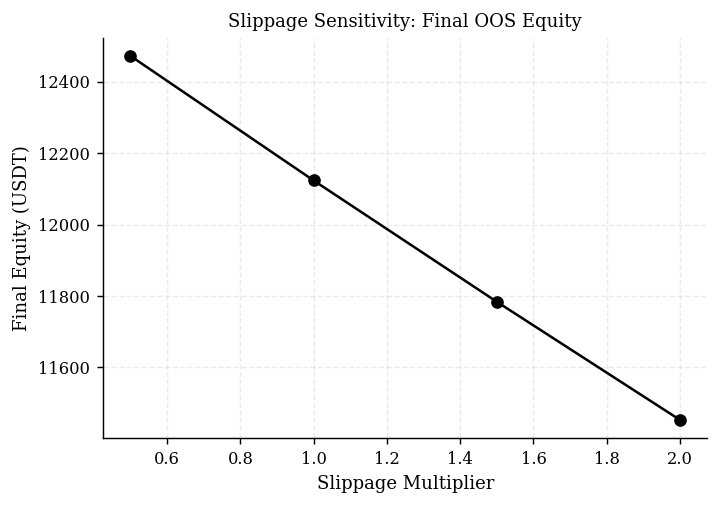

In [39]:
# ── Performance Metrics ───────────────────────────────────────────
bh_ret = ret_df.reindex(oos_sig.index).fillna(0.0).mean(axis=1)
bh_equity = STARTING_CAPITAL * (1 + bh_ret).cumprod()
trend_gross_pnl = trend_portfolio["gross_ret"].fillna(0.0) * trend_portfolio["equity"].shift(1).fillna(STARTING_CAPITAL)
trend_net_pnl = trend_portfolio["net_ret"].fillna(0.0) * trend_portfolio["equity"].shift(1).fillna(STARTING_CAPITAL)
trend_gross_equity = STARTING_CAPITAL + trend_gross_pnl.cumsum()
gross_portfolio = trend_portfolio.copy()
gross_portfolio["equity"] = trend_gross_equity
gross_portfolio["net_ret"] = gross_portfolio["gross_ret"]
gross_portfolio["tcost"] = 0.0
gross_portfolio["npnl_usdt"] = trend_gross_pnl
trend_portfolio["npnl_usdt"] = trend_net_pnl
buy_hold_portfolio = pd.DataFrame(
    {
        "net_ret": bh_ret,
        "gross_ret": bh_ret,
        "equity": bh_equity,
        "turnover": 0.0,
        "gross_exposure": 1.0,
        "net_exposure": 1.0,
        "tcost": 0.0,
    },
    index=bh_ret.index,
)
buy_hold_portfolio["npnl_usdt"] = bh_equity.diff().fillna(STARTING_CAPITAL * bh_ret.iloc[0])

trend_net_summary = compute_performance_summary(
    trend_portfolio,
    STARTING_CAPITAL,
    return_col="net_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
trend_gross_summary = compute_performance_summary(
    gross_portfolio,
    STARTING_CAPITAL,
    return_col="gross_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
bh_summary = compute_performance_summary(
    buy_hold_portfolio,
    STARTING_CAPITAL,
    return_col="net_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
holding_summary, holding_by_asset = compute_holding_horizon_stats(trend_theta)
performance_table = pd.DataFrame(
    {
        "Signed Trend-Following (Gross)": trend_gross_summary,
        "Signed Trend-Following (Net)": trend_net_summary,
        "Equal-Wt Buy & Hold": bh_summary,
    }
).T
performance_report = performance_table[
    [
        "final_equity",
        "total_pnl_usdt",
        "pct_return",
        "ann_return",
        "ann_vol",
        "sharpe",
        "sortino",
        "calmar",
        "max_drawdown",
    ]
].rename(
    columns={
        "final_equity": "Final Equity",
        "total_pnl_usdt": "Total PnL (USDT)",
        "pct_return": "Return on Initial Capital",
        "ann_return": "Ann. Return",
        "ann_vol": "Ann. Vol",
        "sharpe": "Sharpe",
        "sortino": "Sortino",
        "calmar": "Calmar",
        "max_drawdown": "Max DD",
    }
)

def _format_report(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ["Final Equity", "Total PnL (USDT)"]:
        out[col] = out[col].map(lambda x: f"{x:,.2f}")
    for col in ["Return on Initial Capital", "Ann. Return", "Ann. Vol", "Max DD"]:
        out[col] = out[col].map(lambda x: f"{x:.2%}")
    for col in ["Sharpe", "Sortino", "Calmar"]:
        out[col] = out[col].map(lambda x: f"{x:.3f}")
    return out

slippage_rows = []
for multiplier in [0.5, 1.0, 1.5, 2.0]:
    scenario_portfolio, _ = run_fixed_oos_backtest(cost_df * multiplier)
    scenario_portfolio["npnl_usdt"] = (
        scenario_portfolio["net_ret"].fillna(0.0)
        * scenario_portfolio["equity"].shift(1).fillna(STARTING_CAPITAL)
    )
    scenario_summary = compute_performance_summary(
        scenario_portfolio,
        STARTING_CAPITAL,
        return_col="net_ret",
        equity_col="equity",
        pnl_col="npnl_usdt",
    )
    slippage_rows.append(
        {
            "slippage_multiplier": multiplier,
            "final_equity": scenario_summary["final_equity"],
            "total_pnl_usdt": scenario_summary["total_pnl_usdt"],
            "ann_return": scenario_summary["ann_return"],
            "sharpe": scenario_summary["sharpe"],
            "calmar": scenario_summary["calmar"],
            "total_transaction_costs": scenario_summary["total_transaction_costs"],
        }
    )
slippage_sensitivity_df = pd.DataFrame(slippage_rows)
slippage_display_df = slippage_sensitivity_df.copy()
slippage_display_df["final_equity"] = slippage_display_df["final_equity"].map(lambda x: f"{x:,.2f}")
slippage_display_df["total_pnl_usdt"] = slippage_display_df["total_pnl_usdt"].map(lambda x: f"{x:,.2f}")
slippage_display_df["ann_return"] = slippage_display_df["ann_return"].map(lambda x: f"{x:.2%}")
slippage_display_df["sharpe"] = slippage_display_df["sharpe"].map(lambda x: f"{x:.3f}")
slippage_display_df["calmar"] = slippage_display_df["calmar"].map(lambda x: f"{x:.3f}")
slippage_display_df["total_transaction_costs"] = slippage_display_df["total_transaction_costs"].map(lambda x: f"{x:,.2f}")

signal_summary = pd.DataFrame(
    {
        "long_frac": (oos_sig > 0).mean(),
        "short_frac": (oos_sig < 0).mean(),
        "flat_frac": oos_sig.eq(0.0).mean(),
        "avg_abs_signal": oos_sig.abs().mean(),
    }
)
gross_cap_reached = bool(trend_theta.abs().sum(axis=1).ge(100_000.0 - 1e-8).any())

print(fold_df.to_string(index=False))
print(
    "\nSanity checks | "
    f"turnover zero on non-rebalance days: {bool(fold_sanity_df['turnover_zero_on_non_rebalance_days'].all())}"
    f"  |  gross exposure drift-only on non-rebalance days: {bool(fold_sanity_df['gross_exposure_drifts_only_on_non_rebalance_days'].all())}"
)
print(
    "Reinvestment / cap note | Profits are reinvested through the evolving equity base, "
    "but target notional exposure remains clipped by the hard gross cap of $100,000. "
    "The strategy therefore scales with equity subject to an absolute exposure ceiling."
)
print(
    f"Final equity: ${trend_net_summary['final_equity']:,.2f}"
    f"  |  Total PnL: ${trend_net_summary['total_pnl_usdt']:,.2f}"
    f"  |  Return on initial capital: {trend_net_summary['pct_return']:.2%}"
)
print(
    f"Total transaction costs: ${trend_net_summary['total_transaction_costs']:,.2f}"
    f"  |  Total turnover: {trend_net_summary['total_turnover']:.4f}"
    f"  |  Average holding horizon: {holding_summary['average_holding_horizon_bars']:.2f} bars"
)
print(
    f"Average gross exposure: {trend_net_summary['avg_gross_exposure']:.4f}"
    f"  |  Max gross exposure: {trend_net_summary['max_gross_exposure']:.4f}"
    f"  |  $100,000 cap reached: {gross_cap_reached}"
)
print(
    f"Average net exposure: {trend_net_summary['avg_net_exposure']:.4f}"
    f"  |  Fraction with shorts: {trend_portfolio['short_assets'].gt(0).mean():.2%}"
    f"  |  Average active assets: {trend_portfolio['active_assets'].mean():.2f}"
)

display(_format_report(performance_report))
display(signal_summary)
display(holding_summary.to_frame(name="value"))
display(holding_by_asset)
display(slippage_display_df)

fig, ax = plt.subplots(figsize=(6, 4), dpi=130)
ax.plot(
    slippage_sensitivity_df["slippage_multiplier"],
    slippage_sensitivity_df["final_equity"],
    color="black",
    marker="o",
    lw=1.4,
)
ax.set_title("Slippage Sensitivity: Final OOS Equity")
ax.set_xlabel("Slippage Multiplier")
ax.set_ylabel("Final Equity (USDT)")
ax.grid(True, ls="--", alpha=0.25)
plt.show()



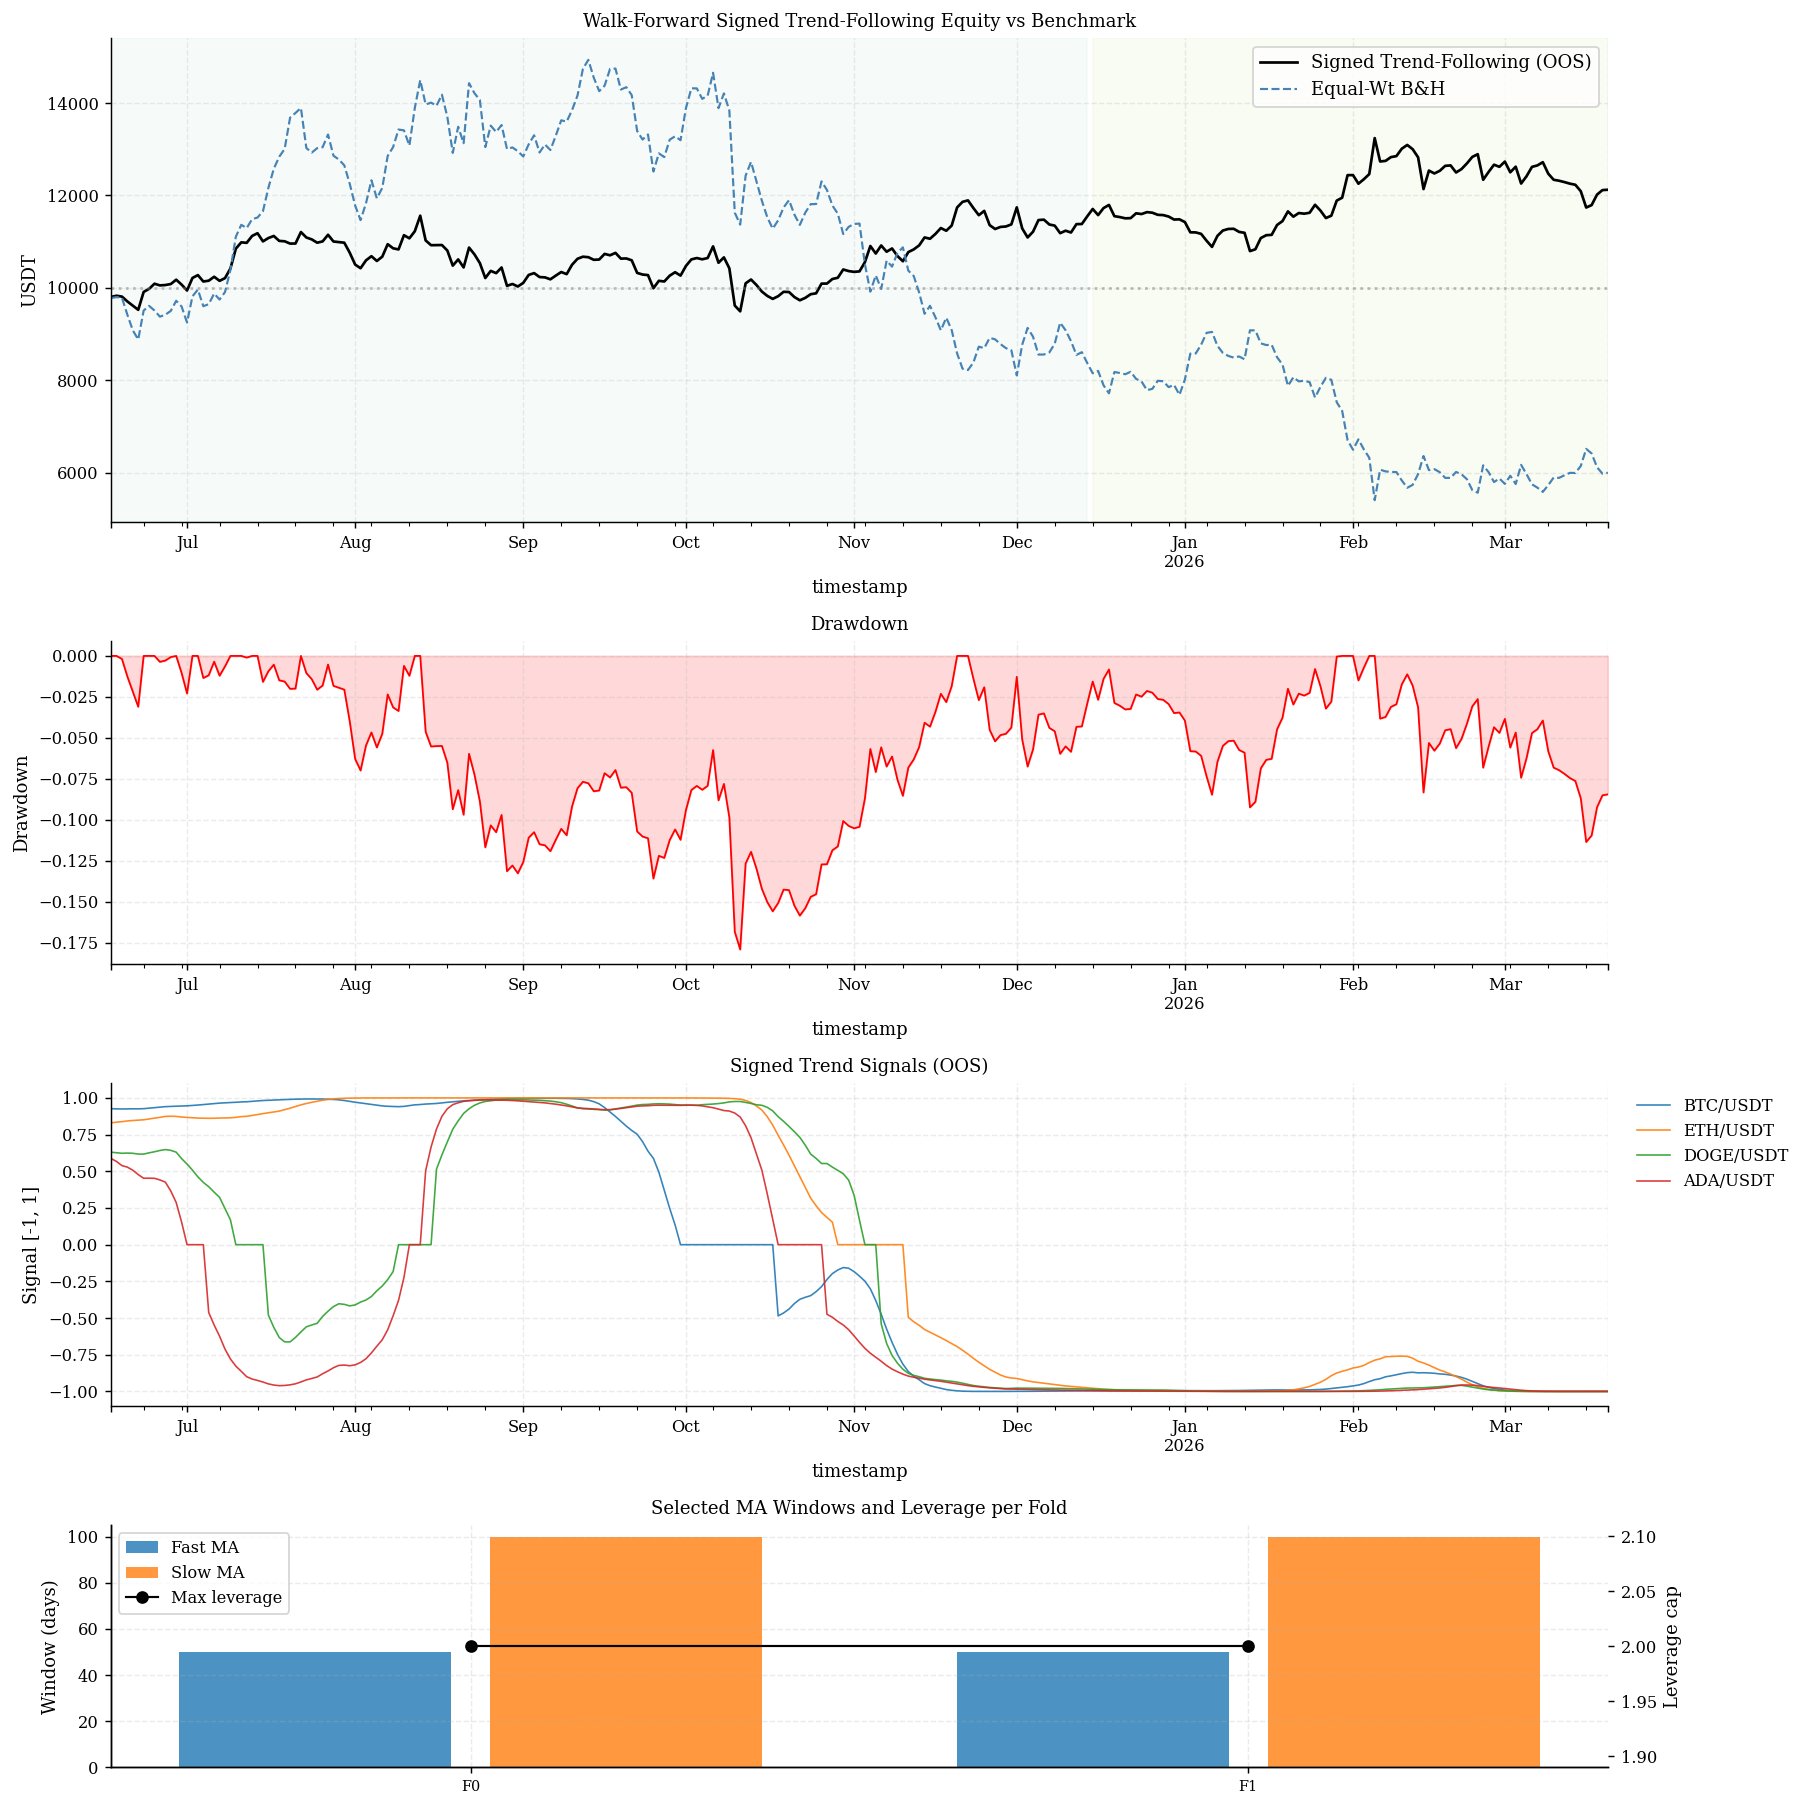

In [40]:
# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 14),
    dpi=130,
    gridspec_kw={"height_ratios": [3, 2, 2, 1.5]},
)

# 1 — Equity vs benchmark
trend_portfolio["equity"].plot(ax=axes[0], color="black", lw=1.5, label="Signed Trend-Following (OOS)")
bh_equity.plot(ax=axes[0], color="steelblue", lw=1.2, ls="--", label="Equal-Wt B&H")
axes[0].axhline(STARTING_CAPITAL, ls=":", color="grey", alpha=0.5)
for j, (sd, ed) in enumerate(wfo_folds):
    axes[0].axvspan(sd, ed, alpha=0.08, color=plt.cm.Set3(j / len(wfo_folds)))
axes[0].set_title("Walk-Forward Signed Trend-Following Equity vs Benchmark")
axes[0].set_ylabel("USDT")
axes[0].legend(fontsize=10)
axes[0].grid(True, ls="--", alpha=0.25)

# 2 — Drawdown
dd_series = trend_portfolio["equity"] / trend_portfolio["equity"].cummax() - 1
dd_series.plot(ax=axes[1], color="red", lw=1)
axes[1].fill_between(dd_series.index, dd_series, 0, alpha=0.15, color="red")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True, ls="--", alpha=0.25)

# 3 — Signed signals
oos_sig.plot(ax=axes[2], lw=0.9, alpha=0.9)
axes[2].set_title("Signed Trend Signals (OOS)")
axes[2].set_ylabel("Signal [-1, 1]")
axes[2].grid(True, ls="--", alpha=0.25)
axes[2].legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)

# 4 — Selected MA parameters and leverage per fold
x = np.arange(len(fold_df))
axes[3].bar(x - 0.2, fold_df["fast"], 0.35, label="Fast MA", alpha=0.8, color="C0")
axes[3].bar(x + 0.2, fold_df["slow"], 0.35, label="Slow MA", alpha=0.8, color="C1")
axes[3].set_xticks(x)
axes[3].set_xticklabels([f"F{i}" for i in x], fontsize=8)
axes[3].set_title("Selected MA Windows and Leverage per Fold")
axes[3].set_ylabel("Window (days)")
axes[3].grid(True, ls="--", alpha=0.25)

lev_ax = axes[3].twinx()
lev_ax.plot(x, fold_df["max_leverage"], color="black", marker="o", lw=1.2, label="Max leverage")
lev_ax.set_ylabel("Leverage cap")

bars_handles, bars_labels = axes[3].get_legend_handles_labels()
lev_handles, lev_labels = lev_ax.get_legend_handles_labels()
axes[3].legend(bars_handles + lev_handles, bars_labels + lev_labels, loc="upper left")

plt.tight_layout()
plt.show()




In [41]:
# ── Persist strategy outputs ──────────────────────────────────────
for sym in symbols:
    cleaned_frames[sym]["trend_signal"] = oos_sig[sym].reindex(cleaned_frames[sym].index)


### Strategy 2: Walk-Forward Cointegration / Pairs Trading

**Economic rationale**: related crypto assets can temporarily diverge from a longer-run equilibrium and then mean-revert once liquidity and positioning pressures fade.

**Model**: for each candidate pair, estimate a rolling hedge ratio, construct a residual spread, standardise it into a z-score, and trade the spread with hysteresis entry / exit rules.

**Implementation**: rank candidate pairs by train-window cointegration quality, trade only the selected pair in each OOS fold, use beta-weighted long/short positions with volatility targeting, enforce the hard $100,000 gross cap, and charge explicit transaction costs from the existing slippage model.

**Validation**: use the same expanding walk-forward train / validation / test structure as Strategy 1, then stitch the OOS fold segments into one continuous backtest.


In [42]:
# === Strategy 2 Configuration / Pair Universe ===
try:
    from statsmodels.tsa.stattools import adfuller, coint
except ImportError:
    adfuller = None
    coint = None
    print("statsmodels not available; pair cointegration diagnostics will fall back to NaNs.")

from itertools import combinations

pair_symbols = symbols[: min(len(symbols), 6)] if FAST_ITERATION_MODE else symbols
PAIR_UNIVERSE = []
for a, b in combinations(pair_symbols, 2):
    pair_close = close_df[[a, b]].dropna()
    if len(pair_close) >= max(180, int(0.80 * len(close_df))):
        PAIR_UNIVERSE.append((a, b))
if not PAIR_UNIVERSE:
    PAIR_UNIVERSE = list(combinations(pair_symbols, 2))

if FAST_ITERATION_MODE:
    PAIR_LOOKBACK_RANGE = [90, 126]
    Z_WINDOW_RANGE = [20, 40]
    ENTRY_Z_RANGE = [1.0, 1.5]
    PAIR_EXIT_RATIO_RANGE = [0.25, 0.5]
    PAIR_TARGET_ANNUAL_VOL_RANGE = [0.20, 0.35]
    PAIR_MAX_LEVERAGE_RANGE = [2.0, 4.0]
    PAIR_TOP_N = 3
else:
    PAIR_LOOKBACK_RANGE = [90, 126, 180]
    Z_WINDOW_RANGE = [20, 40, 60]
    ENTRY_Z_RANGE = [1.0, 1.5, 2.0]
    PAIR_EXIT_RATIO_RANGE = [0.25, 0.5, 0.75]
    PAIR_TARGET_ANNUAL_VOL_RANGE = [0.20, 0.35, 0.50]
    PAIR_MAX_LEVERAGE_RANGE = [2.0, 4.0, 6.0]
    PAIR_TOP_N = 5

PAIR_SIGNAL_PARAM_GRID = list(product(PAIR_LOOKBACK_RANGE, Z_WINDOW_RANGE, ENTRY_Z_RANGE, PAIR_EXIT_RATIO_RANGE))
PAIR_PORTFOLIO_PARAM_GRID = list(product(PAIR_TARGET_ANNUAL_VOL_RANGE, PAIR_MAX_LEVERAGE_RANGE))
PAIR_DEFAULT_PORTFOLIO_KEY = (0.35, 4.0)

print(f"Candidate pairs: {len(PAIR_UNIVERSE)}")
print(f"Pair signal grid: {len(PAIR_SIGNAL_PARAM_GRID)}  |  Pair portfolio grid: {len(PAIR_PORTFOLIO_PARAM_GRID)}")


Candidate pairs: 6
Pair signal grid: 16  |  Pair portfolio grid: 4


In [43]:
# === Strategy 2 Helpers / Caches ===
def estimate_rolling_beta(log_y: pd.Series, log_x: pd.Series, lookback: int) -> pd.Series:
    beta = pd.Series(np.nan, index=log_y.index, dtype=float)
    for i in range(lookback, len(log_y)):
        y_hist = log_y.iloc[i - lookback:i]
        x_hist = log_x.iloc[i - lookback:i]
        hist = pd.concat([y_hist, x_hist], axis=1).dropna()
        if len(hist) < lookback:
            continue
        X = np.column_stack([np.ones(len(hist)), hist.iloc[:, 1].values])
        coef = np.linalg.lstsq(X, hist.iloc[:, 0].values, rcond=None)[0]
        beta.iloc[i] = float(np.clip(coef[1], -5.0, 5.0))
    return beta.ffill()


def build_pair_spread(log_y: pd.Series, log_x: pd.Series, beta_series: pd.Series) -> pd.Series:
    return log_y - beta_series * log_x


def pair_cointegration_stats(train_log_y: pd.Series, train_log_x: pd.Series) -> dict:
    data = pd.concat([train_log_y, train_log_x], axis=1).dropna()
    if len(data) < 60:
        return {
            "coint_pvalue": np.nan,
            "hedge_beta_fullsample": np.nan,
            "adf_stat": np.nan,
        }

    X = np.column_stack([np.ones(len(data)), data.iloc[:, 1].values])
    coef = np.linalg.lstsq(X, data.iloc[:, 0].values, rcond=None)[0]
    beta = float(np.clip(coef[1], -5.0, 5.0))
    spread = data.iloc[:, 0] - beta * data.iloc[:, 1]

    pvalue = np.nan
    if coint is not None:
        try:
            _, pvalue, _ = coint(data.iloc[:, 0], data.iloc[:, 1])
        except Exception:
            pvalue = np.nan

    adf_stat = np.nan
    if adfuller is not None:
        try:
            adf_stat = float(adfuller(spread.dropna(), maxlag=1, regression="c", autolag=None)[0])
        except Exception:
            adf_stat = np.nan

    return {
        "coint_pvalue": pvalue,
        "hedge_beta_fullsample": beta,
        "adf_stat": adf_stat,
    }


def build_pair_signal(close_df_pair: pd.DataFrame, lookback: int, z_window: int, entry_z: float, exit_ratio: float) -> pd.DataFrame:
    y, x = close_df_pair.columns.tolist()
    log_y = np.log(close_df_pair[y].replace(0.0, np.nan))
    log_x = np.log(close_df_pair[x].replace(0.0, np.nan))
    beta_series = estimate_rolling_beta(log_y, log_x, lookback)
    spread = build_pair_spread(log_y, log_x, beta_series)
    spread_mean = spread.rolling(z_window, min_periods=max(10, z_window // 2)).mean()
    spread_std = spread.rolling(z_window, min_periods=max(10, z_window // 2)).std().replace(0.0, np.nan)
    zscore = (spread - spread_mean) / spread_std

    raw_state = pd.Series(0.0, index=close_df_pair.index, dtype=float)
    state = 0.0
    for dt, value in zscore.items():
        if pd.notna(value):
            if value > entry_z:
                state = -1.0
            elif value < -entry_z:
                state = 1.0
            elif abs(value) < entry_z * exit_ratio:
                state = 0.0
        raw_state.loc[dt] = state

    trade_state = raw_state.shift(1).fillna(0.0)
    trade_strength = np.tanh(zscore.abs()).shift(1).fillna(0.0)
    signal = trade_state * trade_strength

    return pd.DataFrame(
        {
            "signal": signal,
            "state": trade_state,
            "zscore": zscore,
            "beta": beta_series,
            "spread": spread,
        },
        index=close_df_pair.index,
    )


pair_signal_cache = {}
for pair in PAIR_UNIVERSE:
    pair_close = close_df[list(pair)].copy()
    for signal_key in PAIR_SIGNAL_PARAM_GRID:
        lookback, z_window, entry_z, exit_ratio = signal_key
        pair_signal_cache[(pair, signal_key)] = build_pair_signal(
            pair_close,
            lookback=lookback,
            z_window=z_window,
            entry_z=entry_z,
            exit_ratio=exit_ratio,
        )

pair_cov_cache = {}
for pair in PAIR_UNIVERSE:
    pair_cols = list(pair)
    for lookback in PAIR_LOOKBACK_RANGE:
        mats = {}
        for dt in all_dates:
            hist = ret_df.loc[ret_df.index < dt, pair_cols].dropna().tail(lookback)
            if len(hist) == lookback:
                mats[dt] = hist.cov().reindex(index=pair_cols, columns=pair_cols).fillna(0.0)
        pair_cov_cache[(pair, lookback)] = mats

print(f"Pair signal combinations cached: {len(pair_signal_cache)}")
print(f"Pair covariance caches built: {len(pair_cov_cache)}")


def run_pairs_strategy_dates(
    pair,
    pair_signal_df,
    sim_dates,
    pair_cov_mats,
    target_annual_vol,
    max_leverage,
    start_equity=STARTING_CAPITAL,
    start_theta=None,
    start_week=None,
    return_state=False,
    cost_input_df=None,
):
    prev_theta = (
        start_theta.copy()
        if start_theta is not None
        else pd.Series(0.0, index=symbols)
    ).astype(float)
    prev_ret = pd.Series(0.0, index=symbols, dtype=float)
    prev_week = start_week
    equity = float(start_equity)
    target_daily_vol = target_annual_vol / np.sqrt(TRADING_DAYS) if target_annual_vol > 0 else 0.0
    rows = []
    theta_rows = []

    pair_y = None if pair is None else pair[0]
    pair_x = None if pair is None else pair[1]

    for i, dt in enumerate(sim_dates):
        eq = max(equity, 1.0)
        ret_t = ret_df.loc[dt].fillna(0.0)
        cost_source_df = cost_df if cost_input_df is None else cost_input_df
        cost_t = cost_source_df.loc[dt].fillna(0.0)

        if i == 0:
            theta_pretrade = prev_theta.copy()
        else:
            theta_pretrade = prev_theta * (1.0 + prev_ret)

        iso = pd.Timestamp(dt).isocalendar()
        week_key = (int(iso.year), int(iso.week))
        scheduled_rebalance = prev_week is None or week_key != prev_week
        did_rebalance = False

        signal_t = float(pair_signal_df.loc[dt, "signal"]) if dt in pair_signal_df.index else 0.0
        state_t = float(pair_signal_df.loc[dt, "state"]) if dt in pair_signal_df.index else 0.0
        beta_t = float(pair_signal_df.loc[dt, "beta"]) if dt in pair_signal_df.index else np.nan
        zscore_t = float(pair_signal_df.loc[dt, "zscore"]) if dt in pair_signal_df.index and pd.notna(pair_signal_df.loc[dt, "zscore"]) else np.nan

        if scheduled_rebalance:
            target_theta = pd.Series(0.0, index=symbols, dtype=float)
            if (
                pair is not None
                and dt in pair_cov_mats
                and state_t != 0.0
                and np.isfinite(beta_t)
                and abs(signal_t) > 0.0
            ):
                raw = pd.Series(0.0, index=symbols, dtype=float)
                raw.loc[pair_y] = state_t
                raw.loc[pair_x] = -state_t * beta_t
                gross_raw = raw.abs().sum()
                if gross_raw > 0:
                    weights = raw / gross_raw
                    cov_t = pair_cov_mats[dt].reindex(index=[pair_y, pair_x], columns=[pair_y, pair_x]).fillna(0.0)
                    weight_vec = weights.loc[[pair_y, pair_x]].values
                    port_var = float(weight_vec.T @ cov_t.values @ weight_vec)
                    realized_daily_vol = np.sqrt(max(port_var, 0.0))
                    if realized_daily_vol > 0:
                        vol_scaler = target_daily_vol / realized_daily_vol
                    else:
                        vol_scaler = 1.0
                    target_notional = min(vol_scaler * eq, max_leverage * eq, 100_000.0)
                    target_notional *= abs(signal_t)
                    target_theta = weights * target_notional
            prev_week = week_key
            did_rebalance = True
        else:
            target_theta = theta_pretrade.copy()

        gross_notional = float(target_theta.abs().sum())
        if gross_notional > 100_000.0:
            target_theta = target_theta * (100_000.0 / gross_notional)

        trade_vector = target_theta - theta_pretrade
        trade_abs = trade_vector.abs()
        tc = float((trade_abs * cost_t).sum())
        gpnl = float((target_theta * ret_t).sum())
        npnl = gpnl - tc
        equity = equity + npnl

        rows.append(
            {
                "equity": equity,
                "gross_ret": gpnl / eq,
                "net_ret": npnl / eq,
                "gpnl_usdt": gpnl,
                "npnl_usdt": npnl,
                "tcost": tc,
                "turnover": float(trade_abs.sum() / eq),
                "gross_exposure": float(target_theta.abs().sum() / eq),
                "net_exposure": float(target_theta.sum() / eq),
                "active_assets": int(target_theta.abs().gt(1e-8).sum()),
                "did_rebalance": did_rebalance,
                "pair_y": pair_y,
                "pair_x": pair_x,
                "beta": beta_t,
                "zscore": zscore_t,
                "signal": signal_t,
                "state": state_t,
            }
        )
        theta_rows.append(target_theta)
        prev_theta = target_theta
        prev_ret = ret_t

    portfolio = pd.DataFrame(rows, index=sim_dates)
    theta_df = pd.DataFrame(theta_rows, index=sim_dates).reindex(columns=symbols, fill_value=0.0)
    portfolio.attrs["theta_df"] = theta_df
    portfolio.attrs["sanity_checks"] = {
        "final_equity": float(portfolio["equity"].iloc[-1]) if len(portfolio) else float(start_equity),
        "total_transaction_costs": float(portfolio["tcost"].sum()) if len(portfolio) else 0.0,
        "average_turnover": float(portfolio["turnover"].mean()) if len(portfolio) else 0.0,
        "average_gross_exposure": float(portfolio["gross_exposure"].mean()) if len(portfolio) else 0.0,
        "max_gross_exposure": float(portfolio["gross_exposure"].max()) if len(portfolio) else 0.0,
    }

    end_theta = prev_theta * (1.0 + prev_ret) if len(sim_dates) > 0 else prev_theta.copy()
    if return_state:
        return portfolio, end_theta, prev_week, equity
    return portfolio


Pair signal combinations cached: 96
Pair covariance caches built: 12


In [44]:
# === Strategy 2 Walk-Forward Optimisation ===
pairs_fold_log = []
pairs_selected_folds = []

for i, (ts, te) in enumerate(wfo_folds):
    train_dates = all_dates[(all_dates >= first_date) & (all_dates < ts)]
    valid_days = min(VALID_DAYS, max(60, len(train_dates) // 4))
    train_inner_dates = train_dates[:-valid_days]
    valid_dates = train_dates[-valid_days:]
    test_dates = all_dates[(all_dates >= ts) & (all_dates <= te)]

    pair_quality_rows = []
    for pair in PAIR_UNIVERSE:
        pair_close_train = close_df.loc[train_dates, list(pair)].dropna()
        stats = pair_cointegration_stats(
            np.log(pair_close_train.iloc[:, 0].replace(0.0, np.nan)),
            np.log(pair_close_train.iloc[:, 1].replace(0.0, np.nan)),
        )
        pair_quality_rows.append(
            {
                "pair": pair,
                "pair_label": f"{pair[0]} / {pair[1]}",
                "coint_pvalue": stats["coint_pvalue"],
                "hedge_beta_fullsample": stats["hedge_beta_fullsample"],
                "adf_stat": stats["adf_stat"],
                "sort_pvalue": stats["coint_pvalue"] if pd.notna(stats["coint_pvalue"]) else np.inf,
            }
        )

    pair_quality_df = pd.DataFrame(pair_quality_rows).sort_values(["sort_pvalue", "pair_label"])
    eligible_pairs_df = pair_quality_df[pair_quality_df["sort_pvalue"] < 0.10]
    if eligible_pairs_df.empty:
        eligible_pairs_df = pair_quality_df.head(PAIR_TOP_N)
    else:
        eligible_pairs_df = eligible_pairs_df.head(PAIR_TOP_N)

    eval_cache = {}

    def evaluate_pair_combo(pair, signal_key, portfolio_key):
        cache_key = (pair, signal_key, portfolio_key)
        if cache_key in eval_cache:
            return eval_cache[cache_key]

        lookback, z_window, entry_z, exit_ratio = signal_key
        target_annual_vol, max_leverage = portfolio_key
        train_full = run_pairs_strategy_dates(
            pair,
            pair_signal_cache[(pair, signal_key)].loc[train_dates],
            train_dates,
            pair_cov_cache[(pair, lookback)],
            target_annual_vol,
            max_leverage,
        )
        inner_train_port = train_full.loc[train_inner_dates]
        valid_port = train_full.loc[valid_dates]
        result = robust_selection_score(inner_train_port, valid_port)
        eval_cache[cache_key] = result
        return result

    best_result = None
    for _, pair_row in eligible_pairs_df.iterrows():
        pair = tuple(pair_row["pair"])
        for signal_key in PAIR_SIGNAL_PARAM_GRID:
            for portfolio_key in PAIR_PORTFOLIO_PARAM_GRID:
                robust_score, train_score, valid_score, train_metrics, valid_metrics = evaluate_pair_combo(
                    pair,
                    signal_key,
                    portfolio_key,
                )
                candidate = {
                    "pair": pair,
                    "pair_label": pair_row["pair_label"],
                    "signal_key": signal_key,
                    "portfolio_key": portfolio_key,
                    "robust_score": robust_score,
                    "train_score": train_score,
                    "valid_score": valid_score,
                    "train_metrics": train_metrics,
                    "valid_metrics": valid_metrics,
                    "coint_pvalue": pair_row["coint_pvalue"],
                    "hedge_beta_fullsample": pair_row["hedge_beta_fullsample"],
                    "adf_stat": pair_row["adf_stat"],
                }
                if best_result is None or candidate["robust_score"] > best_result["robust_score"]:
                    best_result = candidate

    used_cash_fallback = (
        best_result is None
        or best_result["robust_score"] <= -900
        or best_result["train_score"] <= -900
        or best_result["valid_score"] <= -900
    )

    if used_cash_fallback:
        fold_cfg = {
            "fold": i,
            "test_dates": test_dates,
            "pair": None,
            "pair_label": "CASH",
            "signal_key": None,
            "target_annual_vol": None,
            "max_leverage": None,
            "used_cash_fallback": True,
        }
        pairs_fold_log.append(
            {
                "fold": i,
                "test_start": str(ts.date()),
                "test_end": str(te.date()),
                "pair_label": "CASH",
                "pair_y": None,
                "pair_x": None,
                "pair_lookback": None,
                "z_window": None,
                "entry_z": None,
                "exit_ratio": None,
                "target_annual_vol": None,
                "max_leverage": None,
                "train_score": round(best_result["train_score"], 3) if best_result is not None else np.nan,
                "valid_score": round(best_result["valid_score"], 3) if best_result is not None else np.nan,
                "robust_score": round(best_result["robust_score"], 3) if best_result is not None else np.nan,
                "coint_pvalue": best_result["coint_pvalue"] if best_result is not None else np.nan,
                "hedge_beta_fullsample": best_result["hedge_beta_fullsample"] if best_result is not None else np.nan,
                "used_cash_fallback": True,
            }
        )
        print(f"  Pairs Fold {i}: {ts.date()} -> {te.date()}  CASH FALLBACK")
    else:
        pair_lookback, z_window, entry_z, exit_ratio = best_result["signal_key"]
        target_annual_vol, max_leverage = best_result["portfolio_key"]
        pair_y, pair_x = best_result["pair"]
        fold_cfg = {
            "fold": i,
            "test_dates": test_dates,
            "pair": best_result["pair"],
            "pair_label": best_result["pair_label"],
            "signal_key": best_result["signal_key"],
            "target_annual_vol": target_annual_vol,
            "max_leverage": max_leverage,
            "used_cash_fallback": False,
        }
        pairs_fold_log.append(
            {
                "fold": i,
                "test_start": str(ts.date()),
                "test_end": str(te.date()),
                "pair_label": best_result["pair_label"],
                "pair_y": pair_y,
                "pair_x": pair_x,
                "pair_lookback": pair_lookback,
                "z_window": z_window,
                "entry_z": entry_z,
                "exit_ratio": exit_ratio,
                "target_annual_vol": target_annual_vol,
                "max_leverage": max_leverage,
                "train_score": round(best_result["train_score"], 3),
                "valid_score": round(best_result["valid_score"], 3),
                "robust_score": round(best_result["robust_score"], 3),
                "coint_pvalue": best_result["coint_pvalue"],
                "hedge_beta_fullsample": best_result["hedge_beta_fullsample"],
                "used_cash_fallback": False,
            }
        )
        print(
            f"  Pairs Fold {i}: {ts.date()} -> {te.date()}  {best_result['pair_label']}  "
            f"lb={pair_lookback}  zwin={z_window}  entry={entry_z:.2f}  exit={exit_ratio:.2f}  "
            f"vol={target_annual_vol:.2f}  lev={max_leverage:.1f}x  p={best_result['coint_pvalue']:.4f}  "
            f"score={best_result['robust_score']:+.3f}"
        )

    pairs_selected_folds.append(fold_cfg)

pairs_fold_df = pd.DataFrame(pairs_fold_log)
pairs_fallback_folds = pairs_fold_df.loc[pairs_fold_df["used_cash_fallback"], "fold"].tolist()
print(f"Pairs fallback folds: {len(pairs_fallback_folds)}")
if pairs_fallback_folds:
    print(f"Pairs fallback fold numbers: {pairs_fallback_folds}")


  Pairs Fold 0: 2025-06-17 -> 2025-12-14  DOGE/USDT / ADA/USDT  lb=90  zwin=20  entry=1.00  exit=0.25  vol=0.35  lev=2.0x  p=0.6075  score=+1.206
  Pairs Fold 1: 2025-12-15 -> 2026-03-20  ETH/USDT / DOGE/USDT  lb=90  zwin=20  entry=1.00  exit=0.50  vol=0.35  lev=2.0x  p=0.0923  score=-0.727
Pairs fallback folds: 0


In [45]:
# === Strategy 2 OOS Stitching ===
pairs_signal_chunks = []
pairs_portfolio_chunks = []
pairs_theta_chunks = []
pairs_boundary_checks = []
prev_theta = pd.Series(0.0, index=symbols)
prev_week = None
equity = STARTING_CAPITAL

for cfg in pairs_selected_folds:
    incoming_theta = prev_theta.copy()
    if cfg["used_cash_fallback"]:
        pair = None
        signal_slice = pd.DataFrame(
            {
                "signal": 0.0,
                "state": 0.0,
                "zscore": np.nan,
                "beta": np.nan,
                "spread": np.nan,
            },
            index=cfg["test_dates"],
        )
        pair_cov_mats = {}
        sim_target_annual_vol = 0.0
        sim_max_leverage = 0.0
        sim_start_week = None
    else:
        pair = cfg["pair"]
        pair_lookback = cfg["signal_key"][0]
        signal_slice = pair_signal_cache[(pair, cfg["signal_key"])].loc[cfg["test_dates"]].copy()
        pair_cov_mats = pair_cov_cache[(pair, pair_lookback)]
        sim_target_annual_vol = cfg["target_annual_vol"]
        sim_max_leverage = cfg["max_leverage"]
        sim_start_week = prev_week

    signal_view = signal_slice.copy()
    signal_view["pair_y"] = None if pair is None else pair[0]
    signal_view["pair_x"] = None if pair is None else pair[1]
    signal_view["fold"] = cfg["fold"]
    pairs_signal_chunks.append(signal_view)

    pairs_fold_portfolio, prev_theta, prev_week, equity = run_pairs_strategy_dates(
        pair,
        signal_slice,
        cfg["test_dates"],
        pair_cov_mats,
        sim_target_annual_vol,
        sim_max_leverage,
        start_equity=equity,
        start_theta=prev_theta,
        start_week=sim_start_week,
        return_state=True,
    )
    pairs_fold_theta = pairs_fold_portfolio.attrs.get("theta_df", pd.DataFrame(index=cfg["test_dates"], columns=symbols)).copy()
    pairs_boundary_checks.append(
        {
            "fold": cfg["fold"],
            "start_theta": incoming_theta,
            "carried_theta": prev_theta.copy(),
        }
    )
    pairs_fold_portfolio.attrs = {}
    pairs_fold_portfolio["fold"] = cfg["fold"]
    pairs_fold_portfolio["pair_label"] = cfg["pair_label"]
    pairs_fold_portfolio["pair_lookback"] = None if cfg["signal_key"] is None else cfg["signal_key"][0]
    pairs_fold_portfolio["z_window"] = None if cfg["signal_key"] is None else cfg["signal_key"][1]
    pairs_fold_portfolio["entry_z"] = None if cfg["signal_key"] is None else cfg["signal_key"][2]
    pairs_fold_portfolio["exit_ratio"] = None if cfg["signal_key"] is None else cfg["signal_key"][3]
    pairs_fold_portfolio["target_annual_vol"] = cfg["target_annual_vol"]
    pairs_fold_portfolio["max_leverage"] = cfg["max_leverage"]
    pairs_fold_portfolio["used_cash_fallback"] = cfg["used_cash_fallback"]
    pairs_portfolio_chunks.append(pairs_fold_portfolio)
    pairs_theta_chunks.append(pairs_fold_theta)

pairs_signal_oos = pd.concat(pairs_signal_chunks).sort_index()
pairs_signal_oos = pairs_signal_oos[~pairs_signal_oos.index.duplicated(keep="first")]
pairs_portfolio = pd.concat(pairs_portfolio_chunks).sort_index()
pairs_theta = pd.concat(pairs_theta_chunks).sort_index()
pairs_theta = pairs_theta[~pairs_theta.index.duplicated(keep="first")]

pairs_boundary_mismatches = []
for i in range(1, len(pairs_boundary_checks)):
    mismatch = (
        pairs_boundary_checks[i]["start_theta"]
        .sub(pairs_boundary_checks[i - 1]["carried_theta"], fill_value=0.0)
        .abs()
        .max()
    )
    pairs_boundary_mismatches.append(float(mismatch))
print(
    f"Pairs fold-boundary carry check | boundaries={len(pairs_boundary_mismatches)}"
    f"  |  max abs mismatch={max(pairs_boundary_mismatches) if pairs_boundary_mismatches else 0.0:.6e}"
)


Pairs fold-boundary carry check | boundaries=1  |  max abs mismatch=0.000000e+00


In [46]:
# === Strategy 2 Evaluation / Reporting ===
def run_pairs_fixed_oos_backtest(cost_input_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    portfolio_chunks = []
    theta_chunks = []
    prev_theta = pd.Series(0.0, index=symbols)
    prev_week = None
    equity = STARTING_CAPITAL

    for cfg in pairs_selected_folds:
        if cfg["used_cash_fallback"]:
            pair = None
            signal_slice = pd.DataFrame(
                {
                    "signal": 0.0,
                    "state": 0.0,
                    "zscore": np.nan,
                    "beta": np.nan,
                    "spread": np.nan,
                },
                index=cfg["test_dates"],
            )
            pair_cov_mats = {}
            sim_target_annual_vol = 0.0
            sim_max_leverage = 0.0
            sim_start_week = None
        else:
            pair = cfg["pair"]
            pair_lookback = cfg["signal_key"][0]
            signal_slice = pair_signal_cache[(pair, cfg["signal_key"])].loc[cfg["test_dates"]]
            pair_cov_mats = pair_cov_cache[(pair, pair_lookback)]
            sim_target_annual_vol = cfg["target_annual_vol"]
            sim_max_leverage = cfg["max_leverage"]
            sim_start_week = prev_week

        fold_portfolio, prev_theta, prev_week, equity = run_pairs_strategy_dates(
            pair,
            signal_slice,
            cfg["test_dates"],
            pair_cov_mats,
            sim_target_annual_vol,
            sim_max_leverage,
            start_equity=equity,
            start_theta=prev_theta,
            start_week=sim_start_week,
            return_state=True,
            cost_input_df=cost_input_df,
        )
        fold_theta = fold_portfolio.attrs.get("theta_df", pd.DataFrame(index=cfg["test_dates"], columns=symbols)).copy()
        fold_portfolio.attrs = {}
        portfolio_chunks.append(fold_portfolio)
        theta_chunks.append(fold_theta)

    stitched_portfolio = pd.concat(portfolio_chunks).sort_index()
    stitched_theta = pd.concat(theta_chunks).sort_index()
    stitched_theta = stitched_theta[~stitched_theta.index.duplicated(keep="first")]
    return stitched_portfolio, stitched_theta

pairs_bh_ret = ret_df.reindex(pairs_portfolio.index).fillna(0.0).mean(axis=1)
pairs_bh_equity = STARTING_CAPITAL * (1 + pairs_bh_ret).cumprod()
pairs_gross_equity = STARTING_CAPITAL + pairs_portfolio["gpnl_usdt"].fillna(0.0).cumsum()
pairs_gross_portfolio = pairs_portfolio.copy()
pairs_gross_portfolio["equity"] = pairs_gross_equity
pairs_gross_portfolio["net_ret"] = pairs_gross_portfolio["gross_ret"]
pairs_gross_portfolio["npnl_usdt"] = pairs_gross_portfolio["gpnl_usdt"]
pairs_gross_portfolio["tcost"] = 0.0
pairs_buy_hold_portfolio = pd.DataFrame(
    {
        "net_ret": pairs_bh_ret,
        "gross_ret": pairs_bh_ret,
        "equity": pairs_bh_equity,
        "turnover": 0.0,
        "gross_exposure": 1.0,
        "net_exposure": 1.0,
        "tcost": 0.0,
    },
    index=pairs_bh_ret.index,
)
pairs_buy_hold_portfolio["npnl_usdt"] = pairs_bh_equity.diff().fillna(STARTING_CAPITAL * pairs_bh_ret.iloc[0])

pairs_net_summary = compute_performance_summary(
    pairs_portfolio,
    STARTING_CAPITAL,
    return_col="net_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
pairs_gross_summary = compute_performance_summary(
    pairs_gross_portfolio,
    STARTING_CAPITAL,
    return_col="gross_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
pairs_bh_summary = compute_performance_summary(
    pairs_buy_hold_portfolio,
    STARTING_CAPITAL,
    return_col="net_ret",
    equity_col="equity",
    pnl_col="npnl_usdt",
)
pairs_holding_summary, pairs_holding_by_asset = compute_holding_horizon_stats(pairs_theta)
pairs_performance_table = pd.DataFrame(
    {
        "Pairs Trading (Gross)": pairs_gross_summary,
        "Pairs Trading (Net)": pairs_net_summary,
        "Equal-Wt Buy & Hold": pairs_bh_summary,
    }
).T
pairs_performance_report = pairs_performance_table[
    [
        "final_equity",
        "total_pnl_usdt",
        "pct_return",
        "ann_return",
        "ann_vol",
        "sharpe",
        "sortino",
        "calmar",
        "max_drawdown",
    ]
].rename(
    columns={
        "final_equity": "Final Equity",
        "total_pnl_usdt": "Total PnL (USDT)",
        "pct_return": "Return on Initial Capital",
        "ann_return": "Ann. Return",
        "ann_vol": "Ann. Vol",
        "sharpe": "Sharpe",
        "sortino": "Sortino",
        "calmar": "Calmar",
        "max_drawdown": "Max DD",
    }
)

pairs_slippage_rows = []
for multiplier in [0.5, 1.0, 1.5, 2.0]:
    scenario_portfolio, _ = run_pairs_fixed_oos_backtest(cost_df * multiplier)
    scenario_summary = compute_performance_summary(
        scenario_portfolio,
        STARTING_CAPITAL,
        return_col="net_ret",
        equity_col="equity",
        pnl_col="npnl_usdt",
    )
    pairs_slippage_rows.append(
        {
            "slippage_multiplier": multiplier,
            "final_equity": scenario_summary["final_equity"],
            "total_pnl_usdt": scenario_summary["total_pnl_usdt"],
            "ann_return": scenario_summary["ann_return"],
            "sharpe": scenario_summary["sharpe"],
            "calmar": scenario_summary["calmar"],
            "total_transaction_costs": scenario_summary["total_transaction_costs"],
        }
    )
pairs_slippage_sensitivity_df = pd.DataFrame(pairs_slippage_rows)

pairs_state_share = pd.Series(
    {
        "live_pair_frac": pairs_portfolio["active_assets"].gt(0).mean(),
        "long_spread_frac": pairs_portfolio["state"].gt(0).mean(),
        "short_spread_frac": pairs_portfolio["state"].lt(0).mean(),
        "flat_frac": pairs_portfolio["state"].eq(0).mean(),
    }
)
pairs_cap_reached = bool(pairs_theta.abs().sum(axis=1).ge(100_000.0 - 1e-8).any())

print(
    f"Pairs final equity: ${pairs_net_summary['final_equity']:,.2f}"
    f"  |  Total PnL: ${pairs_net_summary['total_pnl_usdt']:,.2f}"
    f"  |  Return on initial capital: {pairs_net_summary['pct_return']:.2%}"
)
print(
    f"Pairs total turnover: {pairs_net_summary['total_turnover']:.4f}"
    f"  |  Average turnover: {pairs_net_summary['avg_turnover']:.4f}"
    f"  |  Average gross exposure: {pairs_net_summary['avg_gross_exposure']:.4f}"
)
print(
    f"Average net exposure: {pairs_net_summary['avg_net_exposure']:.4f}"
    f"  |  Max gross exposure: {pairs_net_summary['max_gross_exposure']:.4f}"
    f"  |  Total transaction costs: ${pairs_net_summary['total_transaction_costs']:,.2f}"
)
print(
    f"Average holding horizon: {pairs_holding_summary['average_holding_horizon_bars']:.2f} bars"
    f"  |  $100,000 cap reached: {pairs_cap_reached}"
    f"  |  Live pair days: {pairs_state_share['live_pair_frac']:.2%}"
)
print(
    f"Long-spread days: {pairs_state_share['long_spread_frac']:.2%}"
    f"  |  Short-spread days: {pairs_state_share['short_spread_frac']:.2%}"
    f"  |  Flat days: {pairs_state_share['flat_frac']:.2%}"
)

display(_format_report(pairs_performance_report))
display(pairs_holding_summary.to_frame(name="value"))
display(pairs_holding_by_asset)
display(pairs_slippage_sensitivity_df)


Pairs final equity: $7,170.04  |  Total PnL: $-2,829.96  |  Return on initial capital: -28.30%
Pairs total turnover: 43.8420  |  Average turnover: 0.1583  |  Average gross exposure: 1.0379
Average net exposure: 0.0370  |  Max gross exposure: 2.2093  |  Total transaction costs: $3,539.17
Average holding horizon: 25.00 bars  |  $100,000 cap reached: False  |  Live pair days: 72.20%
Long-spread days: 35.38%  |  Short-spread days: 36.46%  |  Flat days: 28.16%


,Final Equity,Total PnL (USDT),Return on Initial Capital,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max DD
Pairs Trading (Gross),"10,709.21",709.21,7.09%,9.46%,31.18%,0.303,0.382,0.450,-21.02%
Pairs Trading (Net),"7,170.04","-2,829.96",-28.30%,-25.14%,32.10%,-0.783,-1.017,-0.695,-36.18%
Equal-Wt Buy & Hold,"5,998.21","-4,001.79",-40.02%,-30.90%,55.61%,-0.556,-0.853,-0.484,-63.81%


,value
average_holding_horizon_bars,25.0
median_holding_horizon_bars,21.0
number_of_holding_runs,16.0


,avg_holding_bars,median_holding_bars,num_runs
asset,,,
BTC/USDT,NaN,NaN,0
ETH/USDT,34.0,34.0,2
DOGE/USDT,25.0,21.0,8
ADA/USDT,22.0,21.0,6


,slippage_multiplier,final_equity,total_pnl_usdt,ann_return,sharpe,calmar,total_transaction_costs
0,0.5,8681.036574,-1318.963426,-0.080353,-0.257204,-0.270216,1928.989755
1,1.0,7170.043925,-2829.956075,-0.251438,-0.783343,-0.694916,3539.169583
2,1.5,5902.075901,-4097.924099,-0.423705,-1.266958,-1.006117,4878.078573
3,2.0,4840.069558,-5159.930442,-0.597414,-1.695835,-1.201395,5987.406242


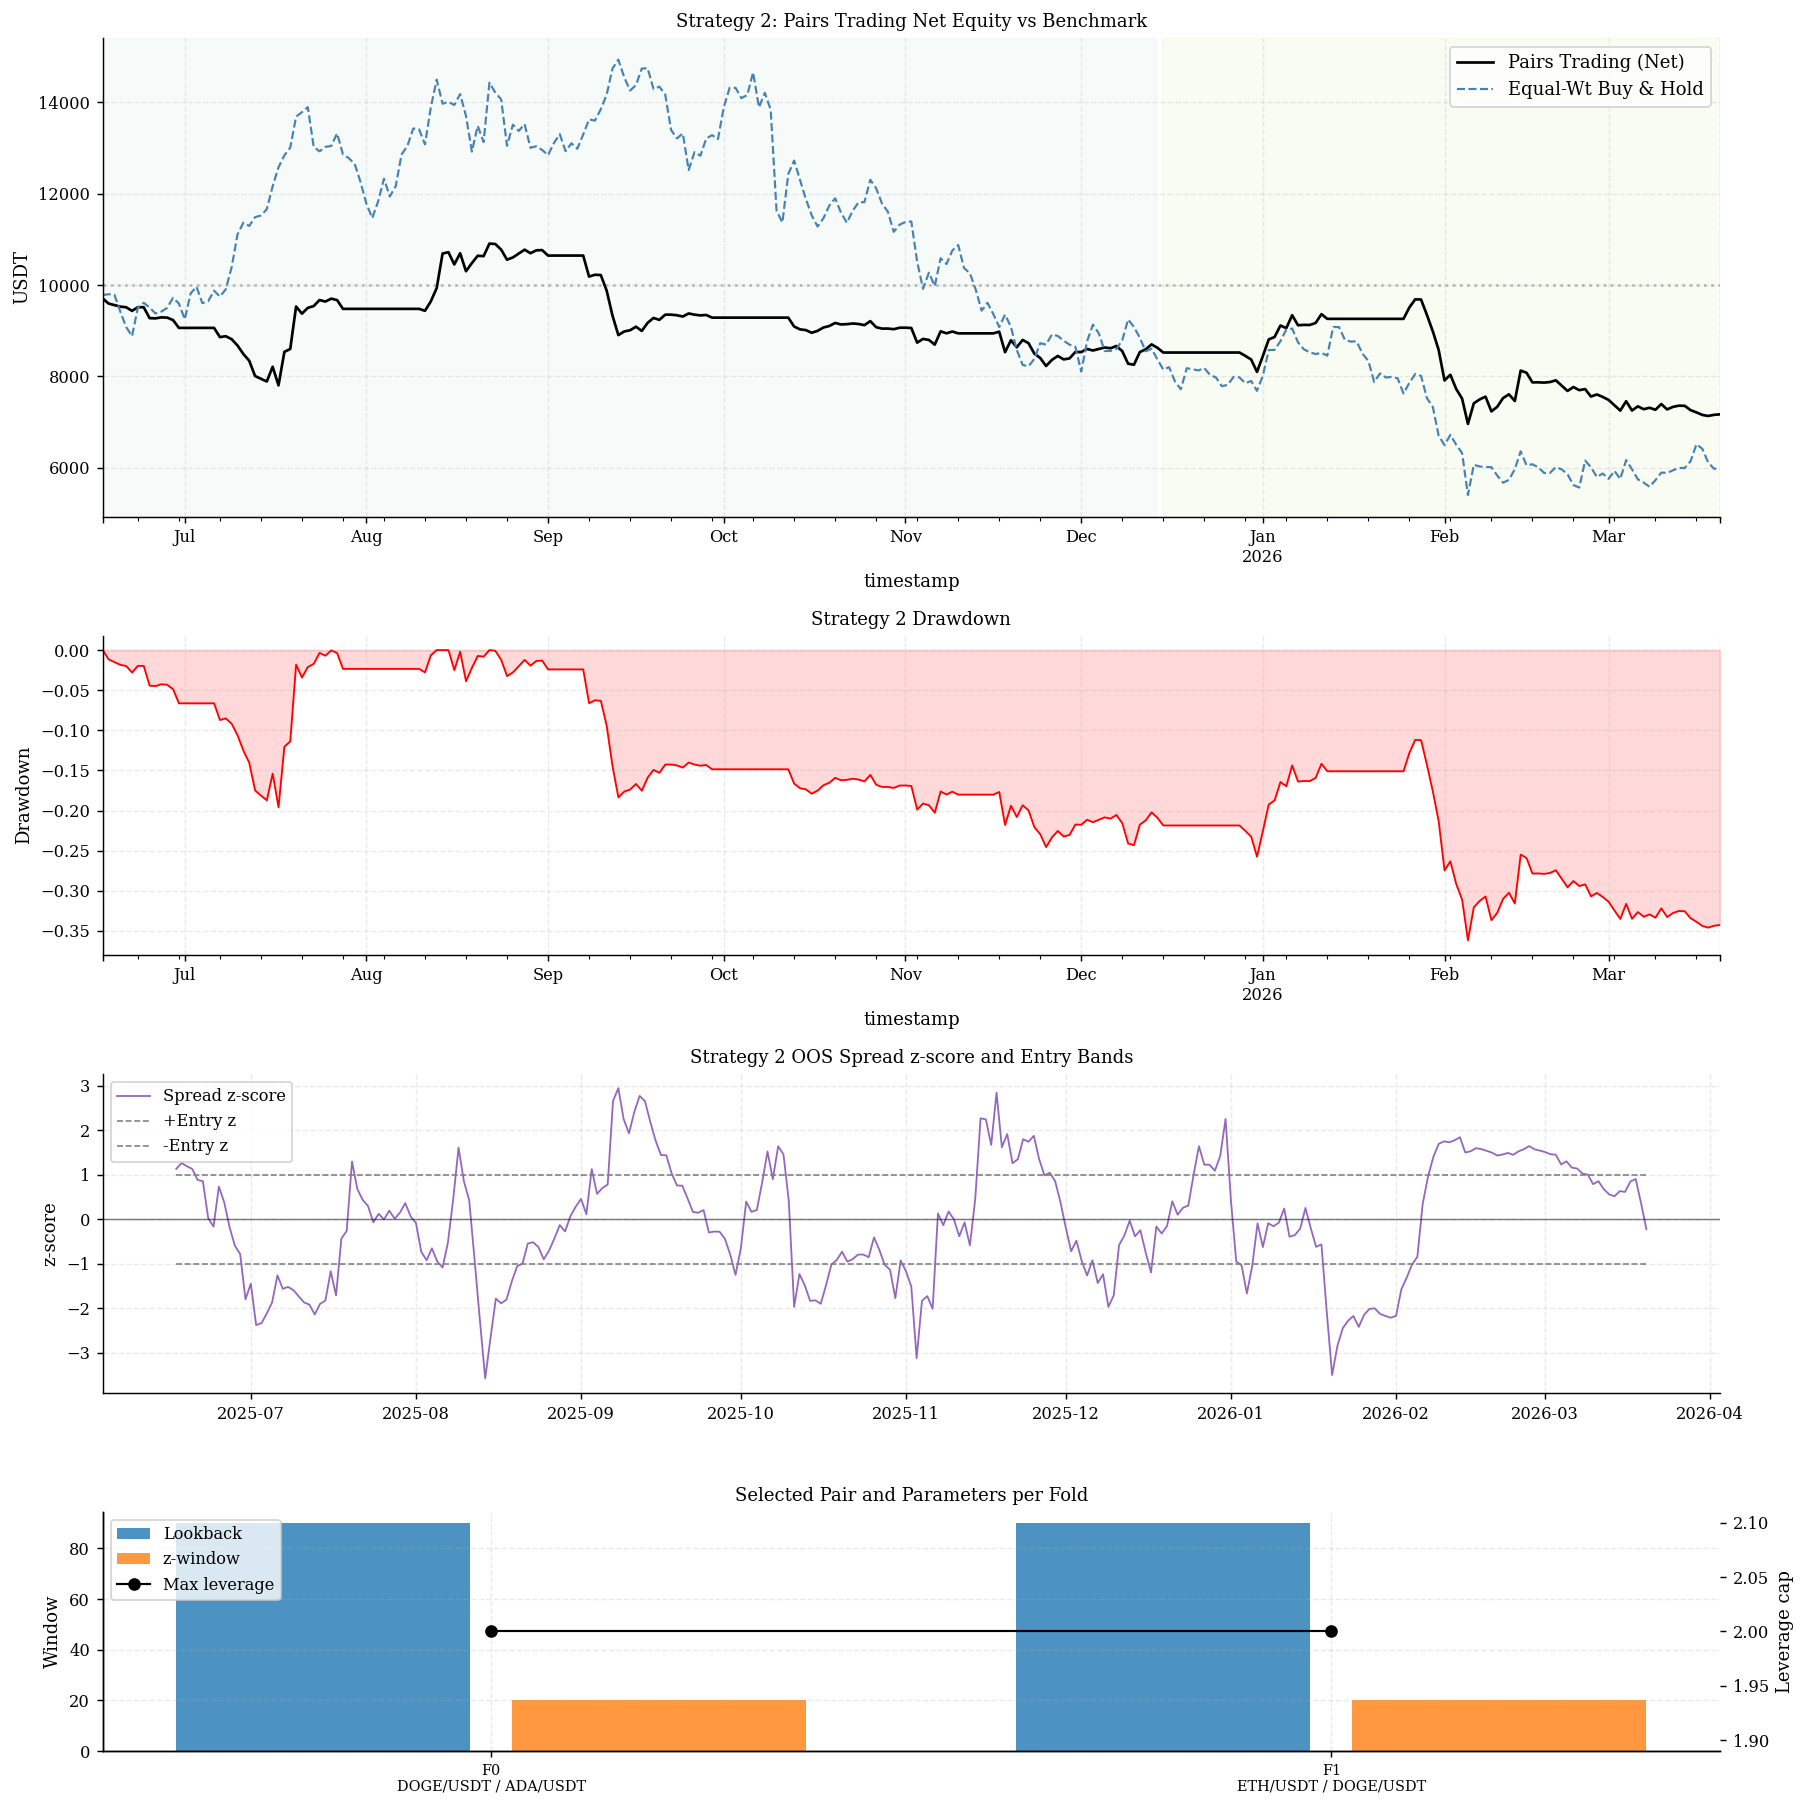

Strategy 2 interpretation
Selected pairs across folds: ['DOGE/USDT / ADA/USDT', 'ETH/USDT / DOGE/USDT']
Behaviour: this is a relative-value mean-reversion strategy using hedge-ratio-adjusted long/short spread positions rather than outright market-direction exposure.
Slippage survival: no at the 2.0x cost scenario based on the fixed OOS replay.
Best regime: correlated, range-bound markets where pair relationships stay stable and temporary dislocations mean-revert.
Weak regime: structural breaks, persistent trends, unstable hedge ratios, or regime shifts that invalidate the historical spread relationship.
Key risks: structural breaks, unstable hedge ratios, false cointegration, regime dependence, and transaction-cost drag.


In [47]:
# === Strategy 2 Visualisation / Interpretation ===
fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 14),
    dpi=130,
    gridspec_kw={"height_ratios": [3, 2, 2, 1.5]},
)

pairs_portfolio["equity"].plot(ax=axes[0], color="black", lw=1.5, label="Pairs Trading (Net)")
pairs_bh_equity.plot(ax=axes[0], color="steelblue", lw=1.2, ls="--", label="Equal-Wt Buy & Hold")
axes[0].axhline(STARTING_CAPITAL, ls=":", color="grey", alpha=0.5)
for j, (sd, ed) in enumerate(wfo_folds):
    axes[0].axvspan(sd, ed, alpha=0.08, color=plt.cm.Set3(j / max(len(wfo_folds), 1)))
axes[0].set_title("Strategy 2: Pairs Trading Net Equity vs Benchmark")
axes[0].set_ylabel("USDT")
axes[0].legend(fontsize=10)
axes[0].grid(True, ls="--", alpha=0.25)

pairs_dd = pairs_portfolio["equity"] / pairs_portfolio["equity"].cummax() - 1.0
pairs_dd.plot(ax=axes[1], color="red", lw=1.0)
axes[1].fill_between(pairs_dd.index, pairs_dd, 0.0, alpha=0.15, color="red")
axes[1].set_title("Strategy 2 Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True, ls="--", alpha=0.25)

axes[2].plot(pairs_portfolio.index, pairs_portfolio["zscore"], color="tab:purple", lw=1.0, label="Spread z-score")
axes[2].plot(pairs_portfolio.index, pairs_portfolio["entry_z"], color="grey", lw=0.9, ls="--", label="+Entry z")
axes[2].plot(pairs_portfolio.index, -pairs_portfolio["entry_z"], color="grey", lw=0.9, ls="--", label="-Entry z")
axes[2].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[2].set_title("Strategy 2 OOS Spread z-score and Entry Bands")
axes[2].set_ylabel("z-score")
axes[2].grid(True, ls="--", alpha=0.25)
axes[2].legend(loc="upper left", fontsize=9)

x = np.arange(len(pairs_fold_df))
axes[3].bar(x - 0.2, pairs_fold_df["pair_lookback"].fillna(0.0), 0.35, label="Lookback", alpha=0.8, color="C0")
axes[3].bar(x + 0.2, pairs_fold_df["z_window"].fillna(0.0), 0.35, label="z-window", alpha=0.8, color="C1")
axes[3].set_xticks(x)
axes[3].set_xticklabels(
    [f"F{i}\n{label}" for i, label in enumerate(pairs_fold_df["pair_label"].fillna("CASH"))],
    fontsize=8,
)
axes[3].set_title("Selected Pair and Parameters per Fold")
axes[3].set_ylabel("Window")
axes[3].grid(True, ls="--", alpha=0.25)

pairs_lev_ax = axes[3].twinx()
pairs_lev_ax.plot(x, pairs_fold_df["max_leverage"].fillna(0.0), color="black", marker="o", lw=1.2, label="Max leverage")
pairs_lev_ax.set_ylabel("Leverage cap")

bars_handles, bars_labels = axes[3].get_legend_handles_labels()
lev_handles, lev_labels = pairs_lev_ax.get_legend_handles_labels()
axes[3].legend(bars_handles + lev_handles, bars_labels + lev_labels, loc="upper left")

plt.tight_layout()
plt.show()

selected_pairs = pairs_fold_df.loc[~pairs_fold_df["used_cash_fallback"], "pair_label"].dropna().tolist()
slippage_survived = bool(
    pairs_slippage_sensitivity_df.loc[
        pairs_slippage_sensitivity_df["slippage_multiplier"] == 2.0,
        "final_equity",
    ].iloc[0] > STARTING_CAPITAL
) if not pairs_slippage_sensitivity_df.empty else False

print("Strategy 2 interpretation")
print(f"Selected pairs across folds: {selected_pairs if selected_pairs else ['none']}")
print(
    "Behaviour: this is a relative-value mean-reversion strategy using hedge-ratio-adjusted long/short spread positions rather than outright market-direction exposure."
)
print(
    f"Slippage survival: {'yes' if slippage_survived else 'no'} at the 2.0x cost scenario based on the fixed OOS replay."
)
print(
    "Best regime: correlated, range-bound markets where pair relationships stay stable and temporary dislocations mean-revert."
)
print(
    "Weak regime: structural breaks, persistent trends, unstable hedge ratios, or regime shifts that invalidate the historical spread relationship."
)
print(
    "Key risks: structural breaks, unstable hedge ratios, false cointegration, regime dependence, and transaction-cost drag."
)
